In [50]:
import pandas as pd
import numpy as np
from itertools import product, combinations
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from pylatexenc.latexencode import unicode_to_latex as text2latex
from scipy import stats


sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.helpers import make_aesthetic, cat_stats
from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula
import random

random.seed(42)
np.random.seed(42)

mypal = make_aesthetic()


def make_bold(x):
	"""
	This function is used to make part of the title bold like as a subtitle.
	Basically, it's using latex to render a (sub)string bold in matplot.
	But make_aesthetic() should handle using Arial for math font,
	so it won't look weird.
	>>> full_title = f"{make_bold("Regression Coefficients of Estimated Prevalence From Multiverse")}\n(Baseline is raw data with no weighting and no dropping)"

	"""
	#
	words = x.split()
	words = ' \\ '.join([w for w in words])  # Escape backslash properly
	bold_str = f"$\\bf{{{words}}}$"  # Correctly format the f-string
	return bold_str

def did_use(x):
    if "never" in x.lower():
        return 0
    else:
        return 1

def short_domain(x):
    if "convention" in x.lower():
        return "conventional"
    elif "moral" in x.lower():
        return "moral"
    elif "personal" in x.lower():
        return "personal"
    else:
        return "other"

df = pd.read_csv("../data/qualtrics_experiments/desc_norms_interface [typing]_August 23, 2025_20.20.csv")
# print(sorted(df.columns))
df = df.iloc[2:]
df = df.query("DistributionChannel=='anonymous'")

data_pts = []
for _, row in df.iterrows():
    # non_loop_merge_vars
    base_pt = {
        "pid": row['ResponseId'],
        "progress": row['Progress'],
        "duration": float(row['Duration (in seconds)'])/60,
        "finished": row['Finished'],
        "feedback": row['feedback'],
        "llm_usage": row['dv_llm_usage'],
        "usage_convention": row['dv_usage_convention'],
        "usage_moral": row['dv_usage_moral'],
        "usage_personal": row['dv_usage_personal'],
        "llm_usage_binary": did_use(row['dv_llm_usage']),
        "usage_convention_binary": did_use(row['dv_usage_convention']),
        "usage_moral_binary": did_use(row['dv_usage_moral']),
        "usage_personal_binary": did_use(row['dv_usage_personal']),
    }

    # loop and merge columns:
    for i in range(1, 60):
        pre = float(row.get(f'{i}_lm_pre_11'))
        post =float( row.get(f'{i}_lm_post_11'))
        qual = row.get(f'{i}_lm_qual')
        if pd.notnull(pre) and pd.notnull(post):
            data_pt = base_pt.copy()
            data_pt['idx'] = i
            data_pt['pre'] = pre
            data_pt['post'] = post
            data_pt['qual'] = qual
            data_pts.append(data_pt)

df = pd.DataFrame(data_pts)
meta_df = pd.read_csv("../data/clean/ai_rot_stimuli_new_prompt.csv")
df = df.merge(meta_df, on='idx', how='left')
df['sum_usage'] = df[['usage_convention_binary', 'usage_moral_binary', 'usage_personal_binary']].sum(axis=1)

df['pre_distance'] = np.abs(df['pre'] - df['rating'])
df['post_distance'] = np.abs(df['post'] - df['rating'])
df['change_distance'] = df['pre_distance'] - df['post_distance']
df['domain'] = df['domain'].map(short_domain)

 # Descriptives of change

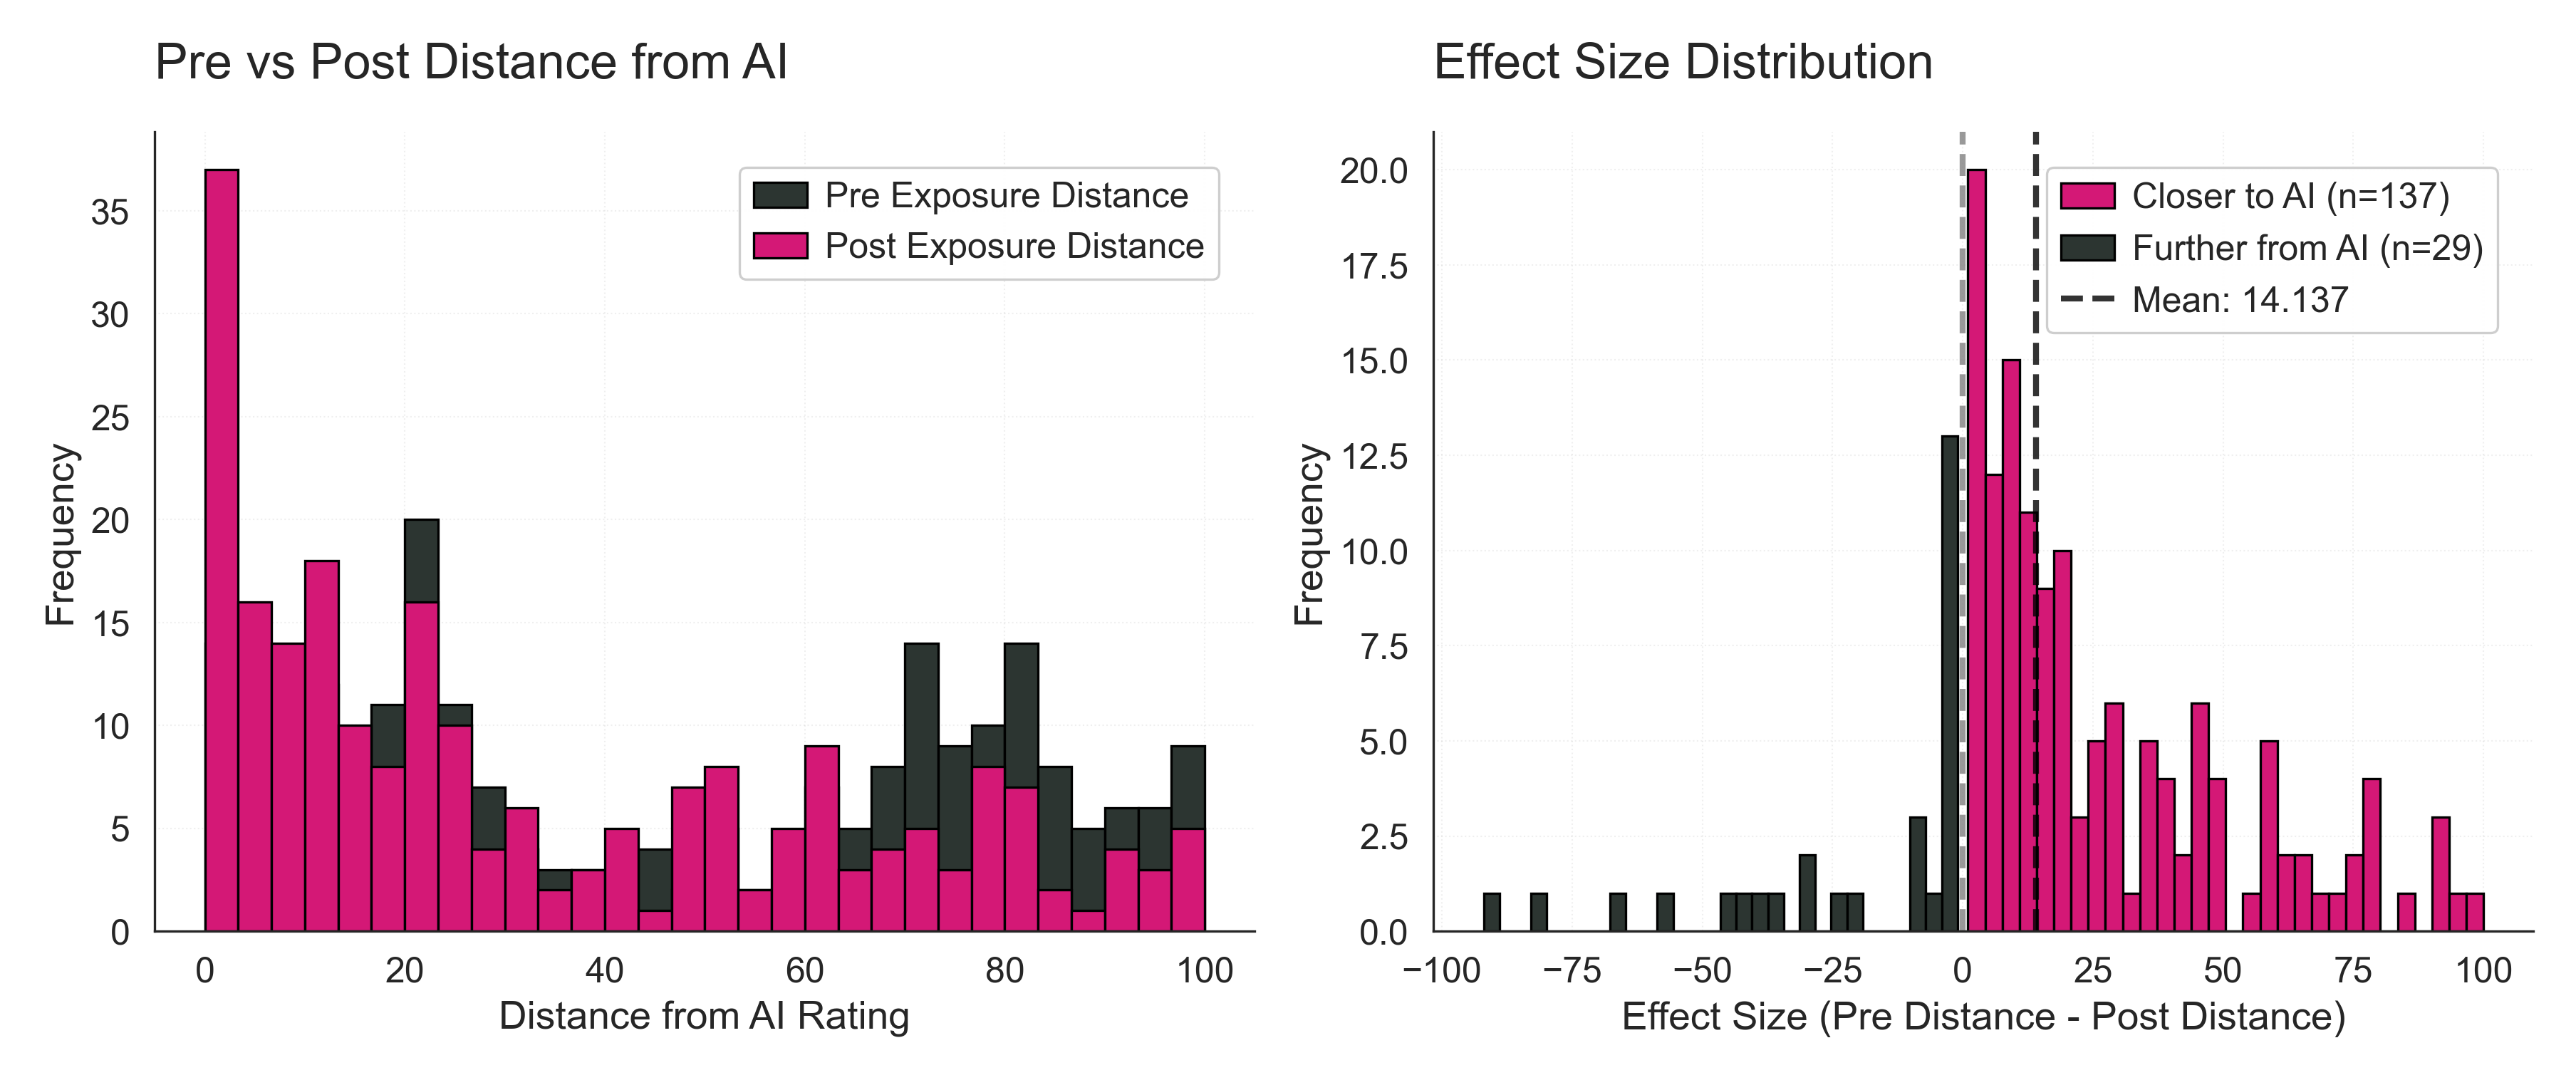


    The mean effect (pre-distance minus post-distance) was 14.14 (SD = 28.42) on an agreement scale of 0-100, with a Cohen's dz of 0.50 (95% CI [0.37, 0.63]), Wilcoxon signed-rank test W = 1886.5, p = 4.1e-16. In 61% of cases, participants moved closer to the AI rating, while in 13% of cases they moved further away, and in 27% of cases there was no change. 


In [107]:
import matplotlib.pyplot as plt
import numpy as np
from src.helpers import array_stats

mypal = make_aesthetic(font_scale=1.2)
effect_size = df['pre_distance'] - df['post_distance']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#################################################################
# Pre_distance and post_distance as overlaid histograms
#################################################################
ax1 = axes[0]
ax1.hist(df['pre_distance'], bins=30, alpha=1, label='Pre Exposure Distance',  edgecolor='black')
ax1.hist(df['post_distance'], bins=30, alpha=1, label='Post Exposure Distance', edgecolor='black')
ax1.set_xlabel('Distance from AI Rating')
ax1.set_ylabel('Frequency')
ax1.set_title('Pre vs Post Distance from AI')
ax1.legend()
ax1.grid(True, alpha=0.3)

#################################################################
# Distribution of effect sizes
#################################################################
ax2 = axes[1]
closer_to_ai = effect_size[effect_size > 0]
further_from_ai = effect_size[effect_size < 0]

ax2.hist(closer_to_ai, bins=30, alpha=1, label=f'Closer to AI (n={len(closer_to_ai)})',
color=mypal[1], edgecolor='black')
ax2.hist(further_from_ai, bins=30, alpha=1, label=f'Further from AI (n={len(further_from_ai)})',
         color=mypal[0], edgecolor='black')
ax2.axvline(0, color='gray', linestyle='--', alpha=0.8, linewidth=2)
ax2.axvline(effect_size.mean(), color='black', linestyle='--', alpha=0.8, linewidth=2,
            label=f'Mean: {effect_size.mean():.3f}')

ax2.set_xlabel('Effect Size (Pre Distance - Post Distance)')
ax2.set_ylabel('Frequency')
ax2.set_title('Effect Size Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Statistics
######################################
######################################
def bootstrap_dz(data, n_bootstraps=10000):
    boot_dz = []
    n = len(data)
    for i in range(n_bootstraps):
        sample = np.random.choice(data, size=n, replace=True)
        mean_diff = np.mean(sample)
        sd_diff = np.std(sample, ddof=1)
        if sd_diff != 0:
            boot_dz.append(mean_diff / sd_diff)
    return np.percentile(boot_dz, [2.5, 97.5])


def compute_change_metrics(pre, post):
    effect_size = pre - post
    mean_diff = effect_size.mean()
    sd_diff = effect_size.std()
    cohens_dz = mean_diff / sd_diff
    ci_lower, ci_upper = bootstrap_dz(effect_size)
    moved_closer = effect_size > 0
    moved_further = effect_size < 0
    no_change = effect_size == 0
    wilcox_w = stats.wilcoxon(pre, post)

    # Calculate percentages
    n = len(effect_size)
    percent_closer = moved_closer.sum() / n
    percent_further = moved_further.sum() / n
    percent_no_change = no_change.sum() / n

    data =  {
        "mean_diff": mean_diff,
        "sd_diff": sd_diff,
        "cohens_dz": cohens_dz,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "moved_closer": moved_closer,
        "moved_further": moved_further,
        "no_change": no_change,
        "wilcox_w": wilcox_w.statistic,
        "wilcox_p": wilcox_w.pvalue
    }
    stats_str = f"""
    The mean effect (pre-distance minus post-distance) was {mean_diff:.2f} (SD = {sd_diff:.2f}) on an agreement scale of 0-100, with a Cohen's dz of {cohens_dz:.2f} (95% CI [{ci_lower:.2f}, {ci_upper:.2f}]), Wilcoxon signed-rank test W = {wilcox_w.statistic}, p = {wilcox_w.pvalue:.1e}. In {percent_closer*100:.0f}% of cases, participants moved closer to the AI rating, while in {percent_further*100:.0f}% of cases they moved further away, and in {percent_no_change*100:.0f}% of cases there was no change. """
    print(stats_str)
    return data

metrics = compute_change_metrics(df['pre_distance'], df['post_distance'])



## By factors

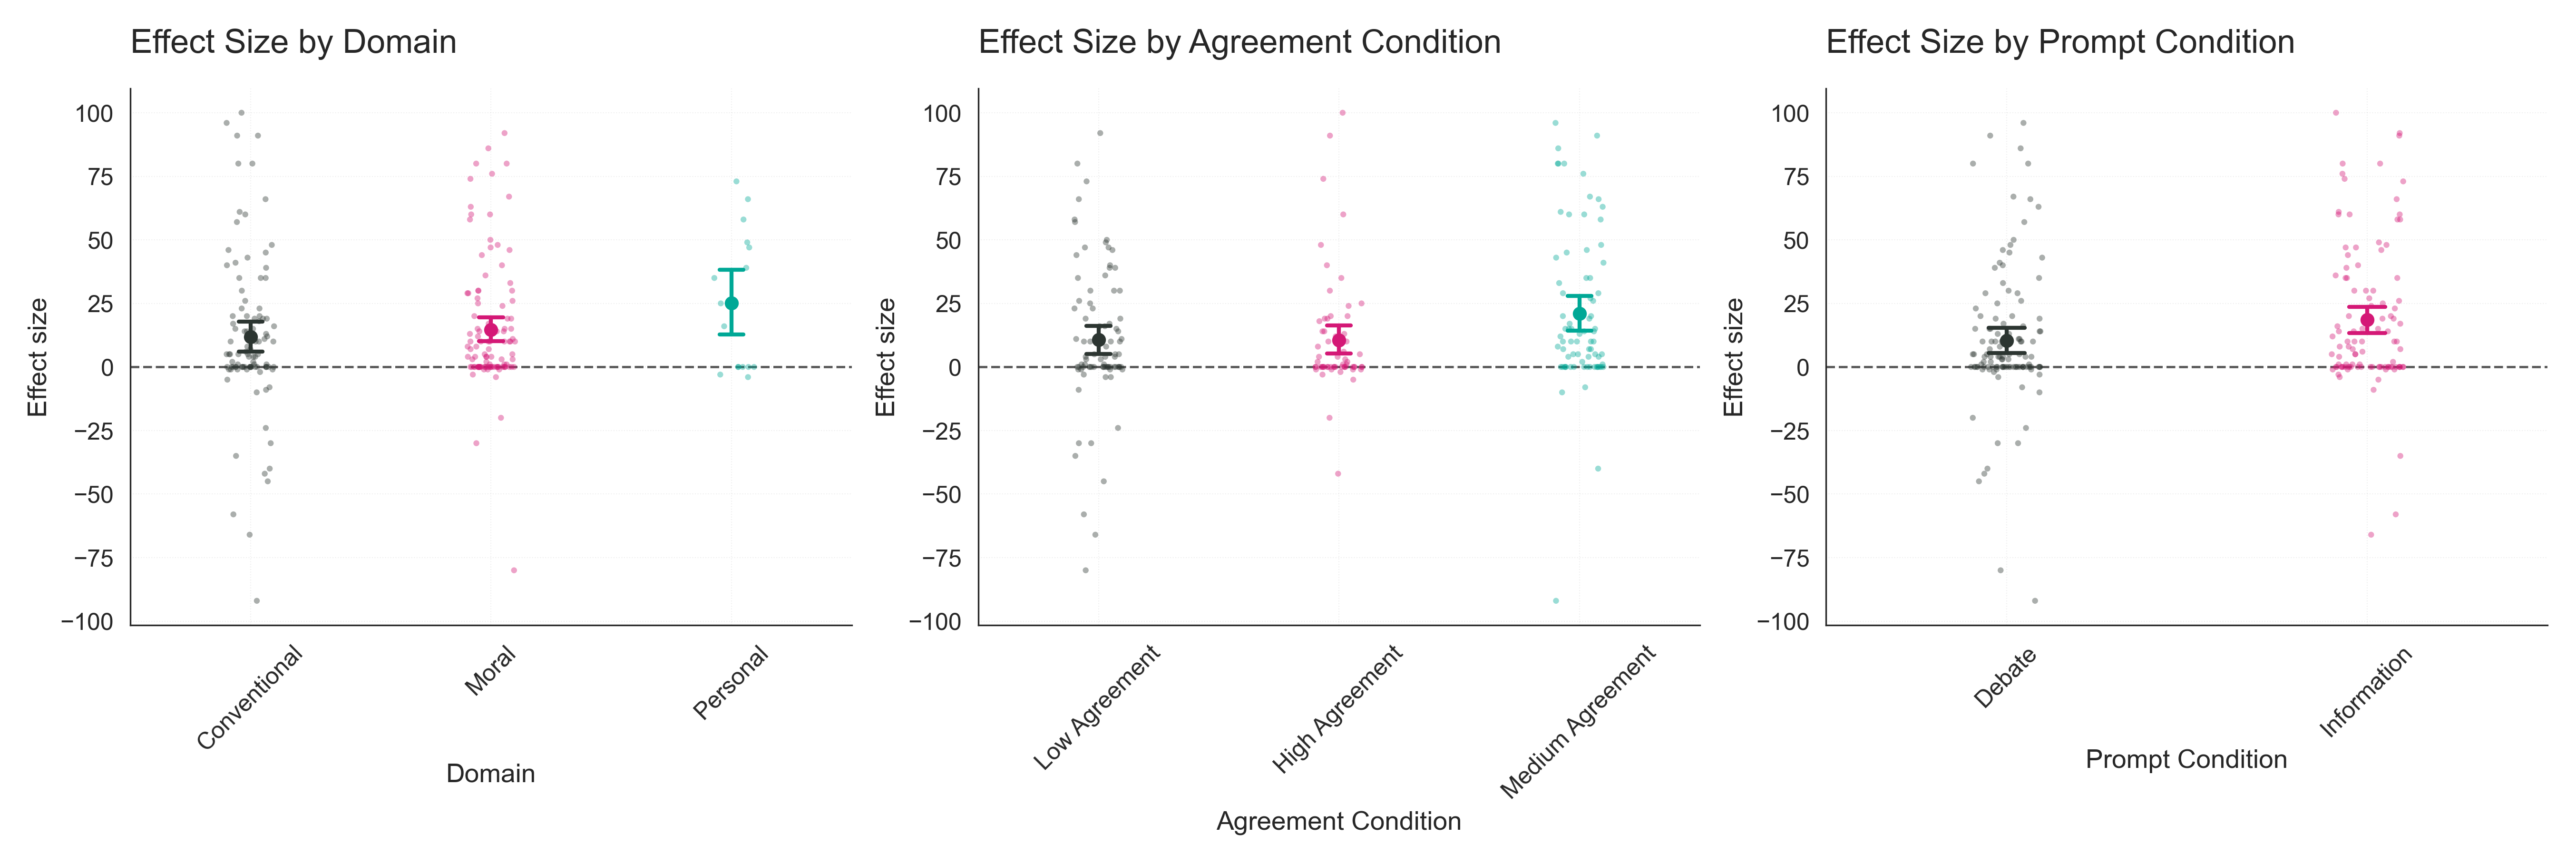

                            OLS Regression Results                            
Dep. Variable:        change_distance   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     4.376
Date:                Sat, 23 Aug 2025   Prob (F-statistic):            0.00746
Time:                        22:57:59   Log-Likelihood:                -1067.2
No. Observations:                 226   AIC:                             2146.
Df Residuals:                     220   BIC:                             2167.
Df Model:                           5                                         
Covariance Type:              cluster                                         
                                                                                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

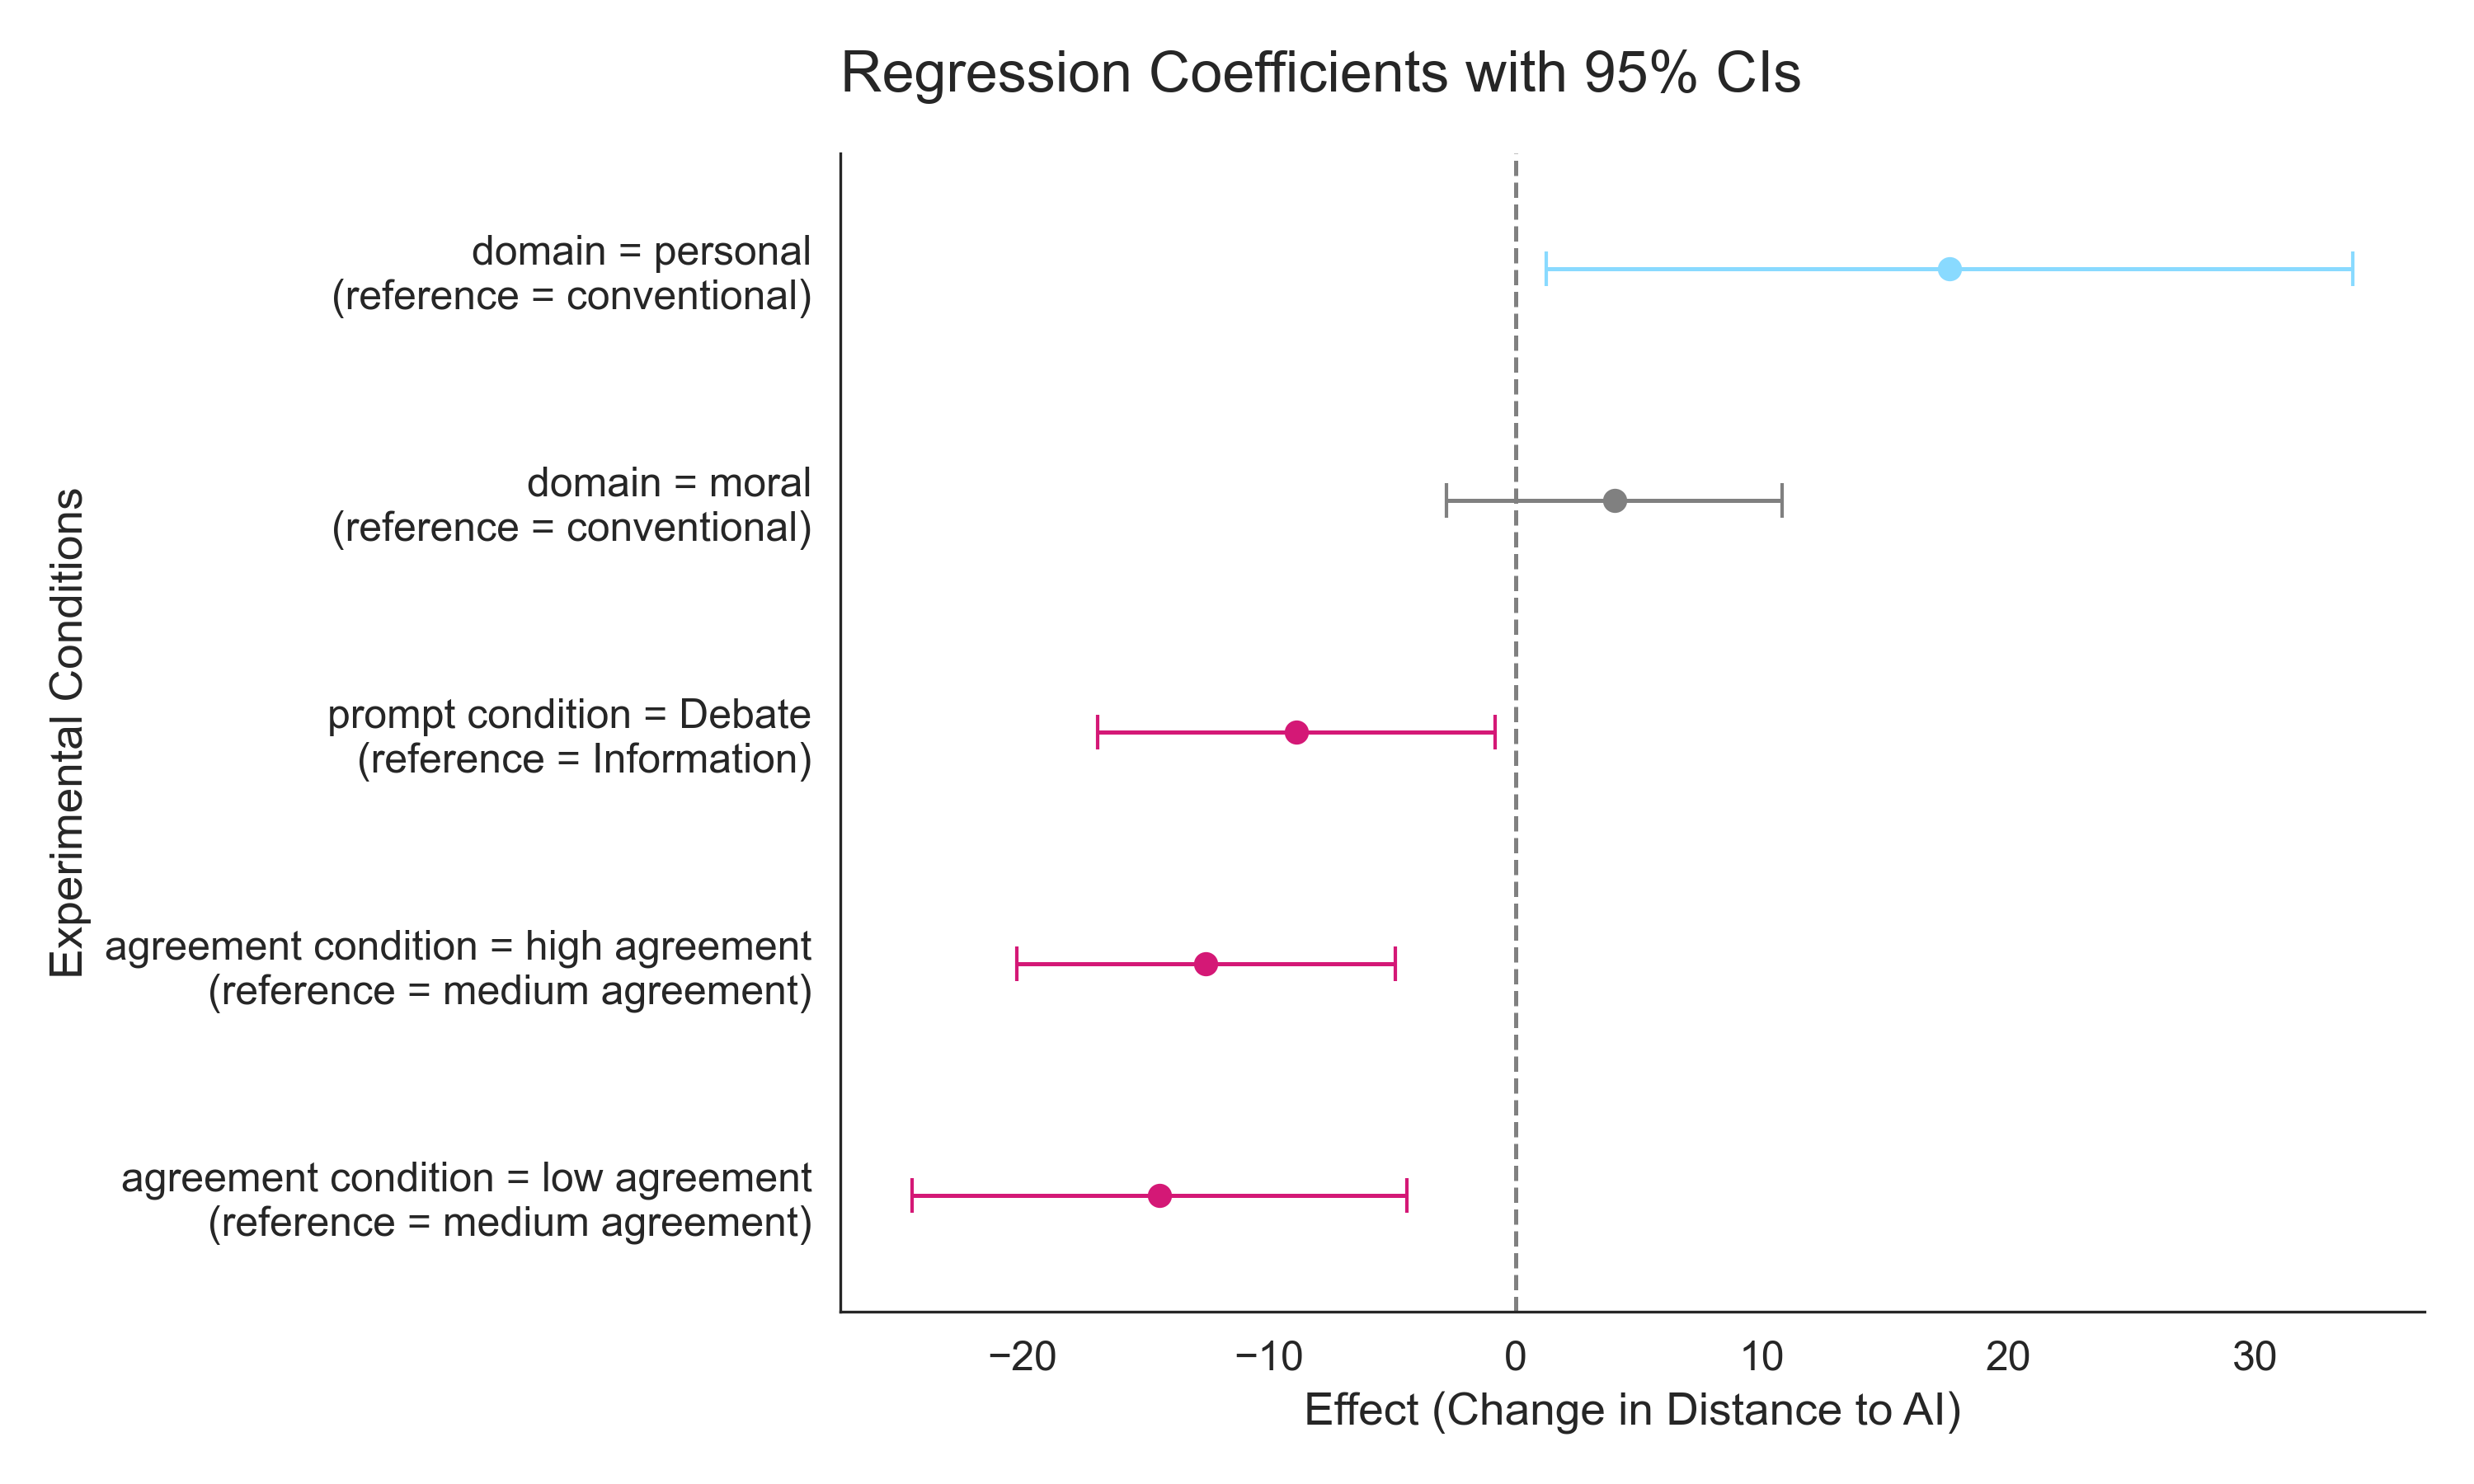

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


# Grid plot by factors
#############################################
#############################################
mypal = make_aesthetic(font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
mypal = make_aesthetic(font_scale=1.2)
factors = ['domain', 'agreement_condition', 'prompt_condition']
factor_titles = ['Domain', 'Agreement Condition', 'Prompt Condition']

for i, (factor, title) in enumerate(zip(factors, factor_titles)):
    ax = axes[i]

    sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
                 capsize=0.1, errwidth=2, ax=ax)

    sns.stripplot(x=factor, y='change_distance', data=df, palette=mypal,
                 alpha=0.4, size=3, ax=ax)

    ax.axhline(y=0, color='k', linestyle='--', alpha=0.7)

    labels = [label.get_text().replace('_', ' ').title() for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=45)

    ax.set_title(f"Effect Size by {title}")
    ax.set_ylabel("Effect size")
    ax.set_xlabel(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#############################################
#############################################


# Regression analysis
#############################################
#############################################

formula = 'change_distance ~ C(domain, Treatment(reference="conventional")) + C(agreement_condition, Treatment(reference="medium_agreement")) + C(prompt_condition, Treatment(reference="Information"))'

model = smf.ols(formula, data=df).fit(
    cov_type='cluster',
    cov_kwds={'groups': df['pid']}
)
print(model.summary())

from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula

handler = StatsmodelsHandler(model)
handler.to_latex()
handler.plot(clean_var_name=clean_var_name_from_formula)
plt.xlabel("Effect (Change in Distance to AI)")
plt.ylabel("Experimental Conditions")
plt.title("Regression Coefficients with 95% CIs")
plt.show()
#############################################
#############################################

# Transition Dynamics

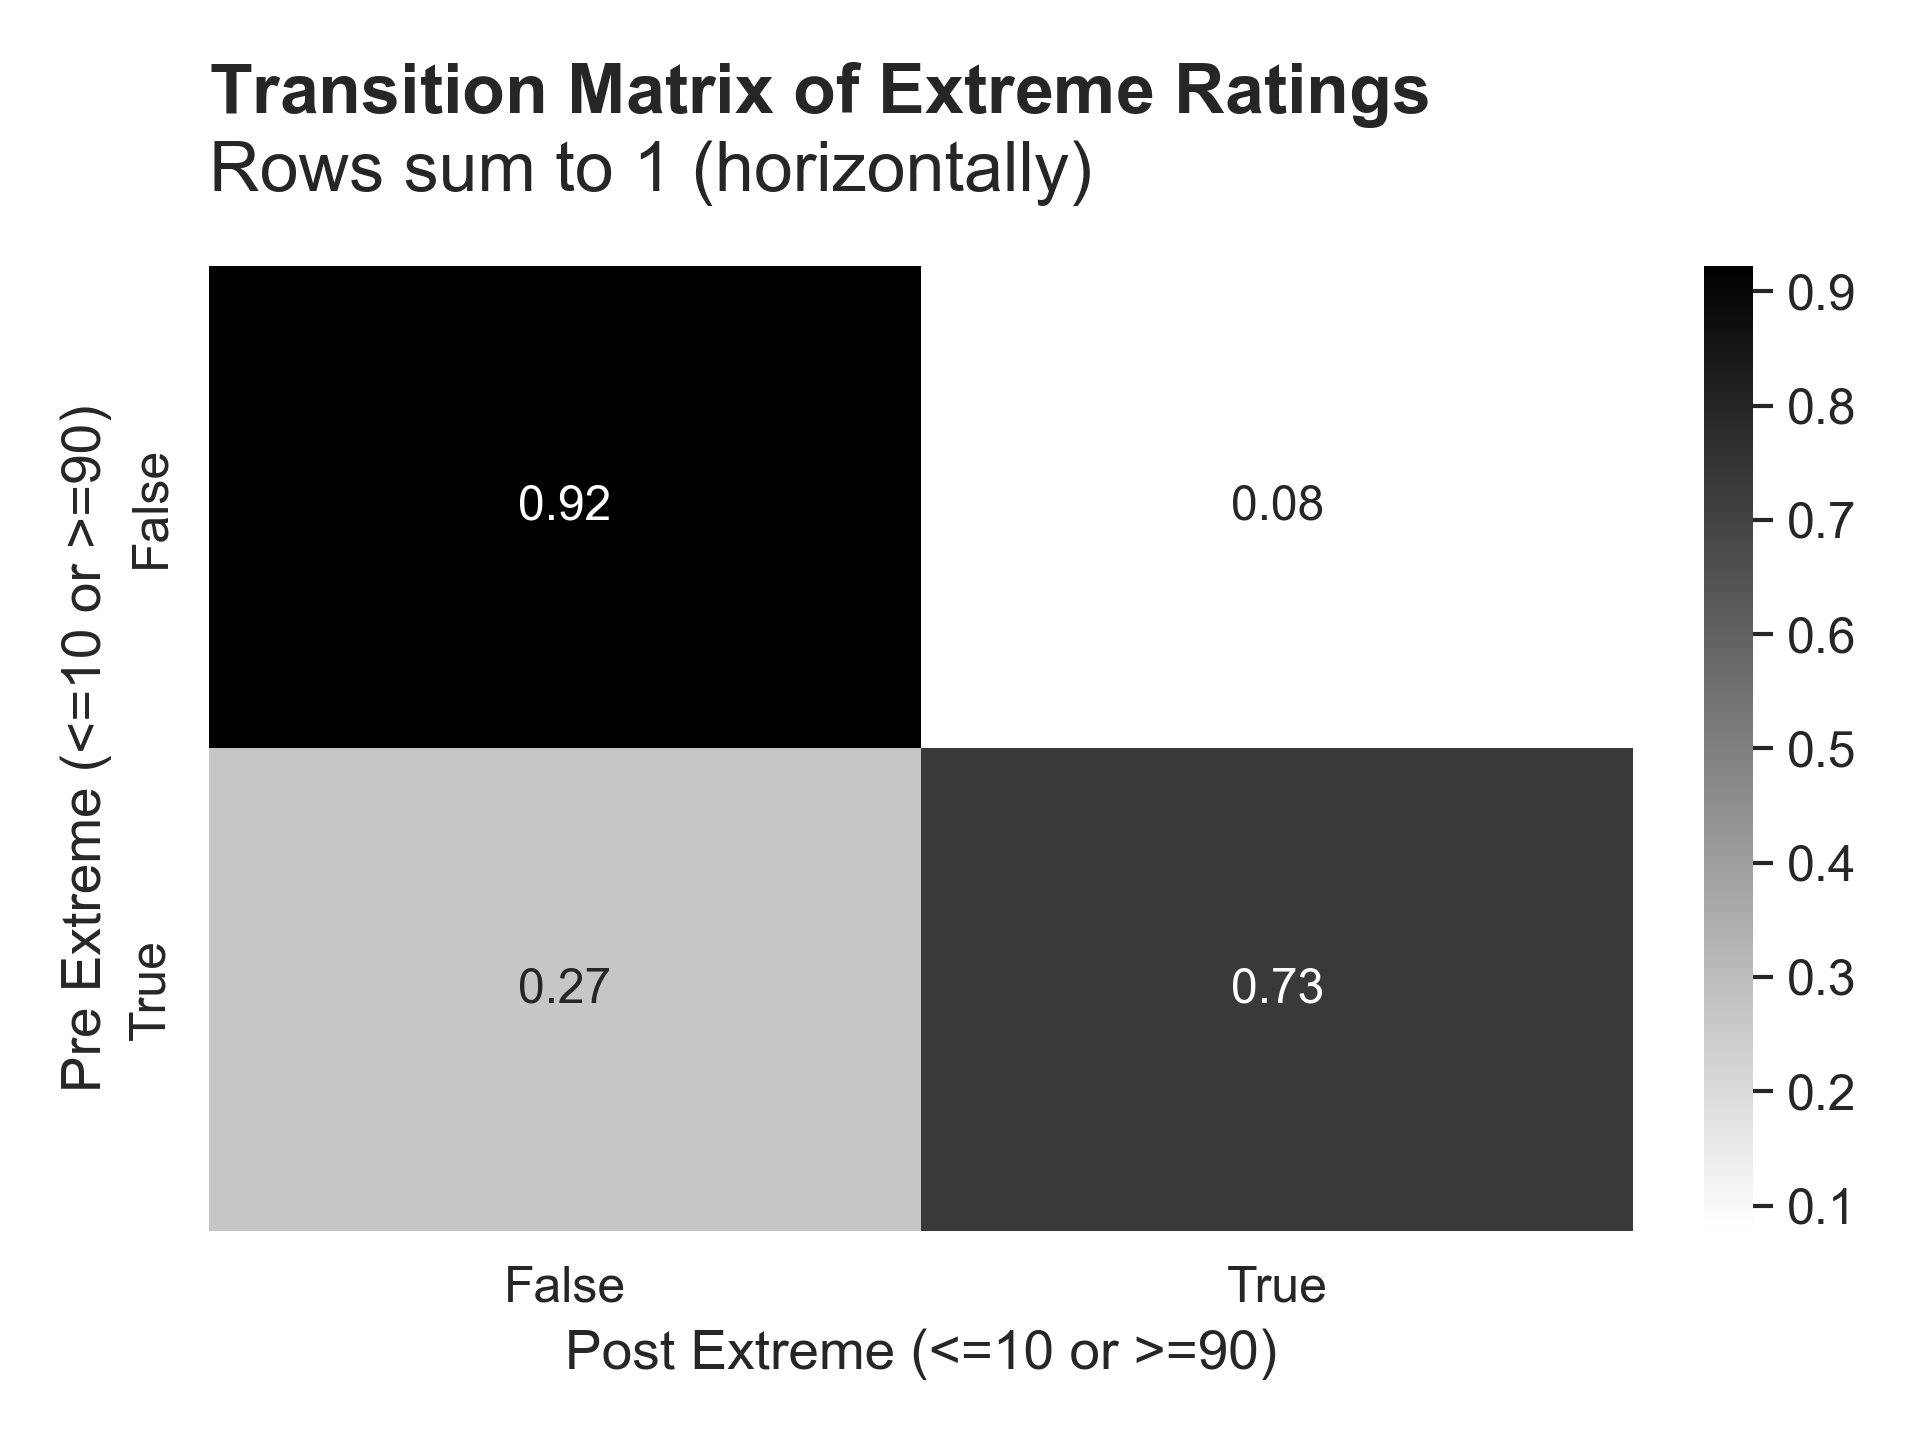

Text(0.0, 1.0, '$\\bf{Transition \\ Matrix \\ of \\ Rating \\ Buckets}$\nRows sum to 1 (horizontally)')

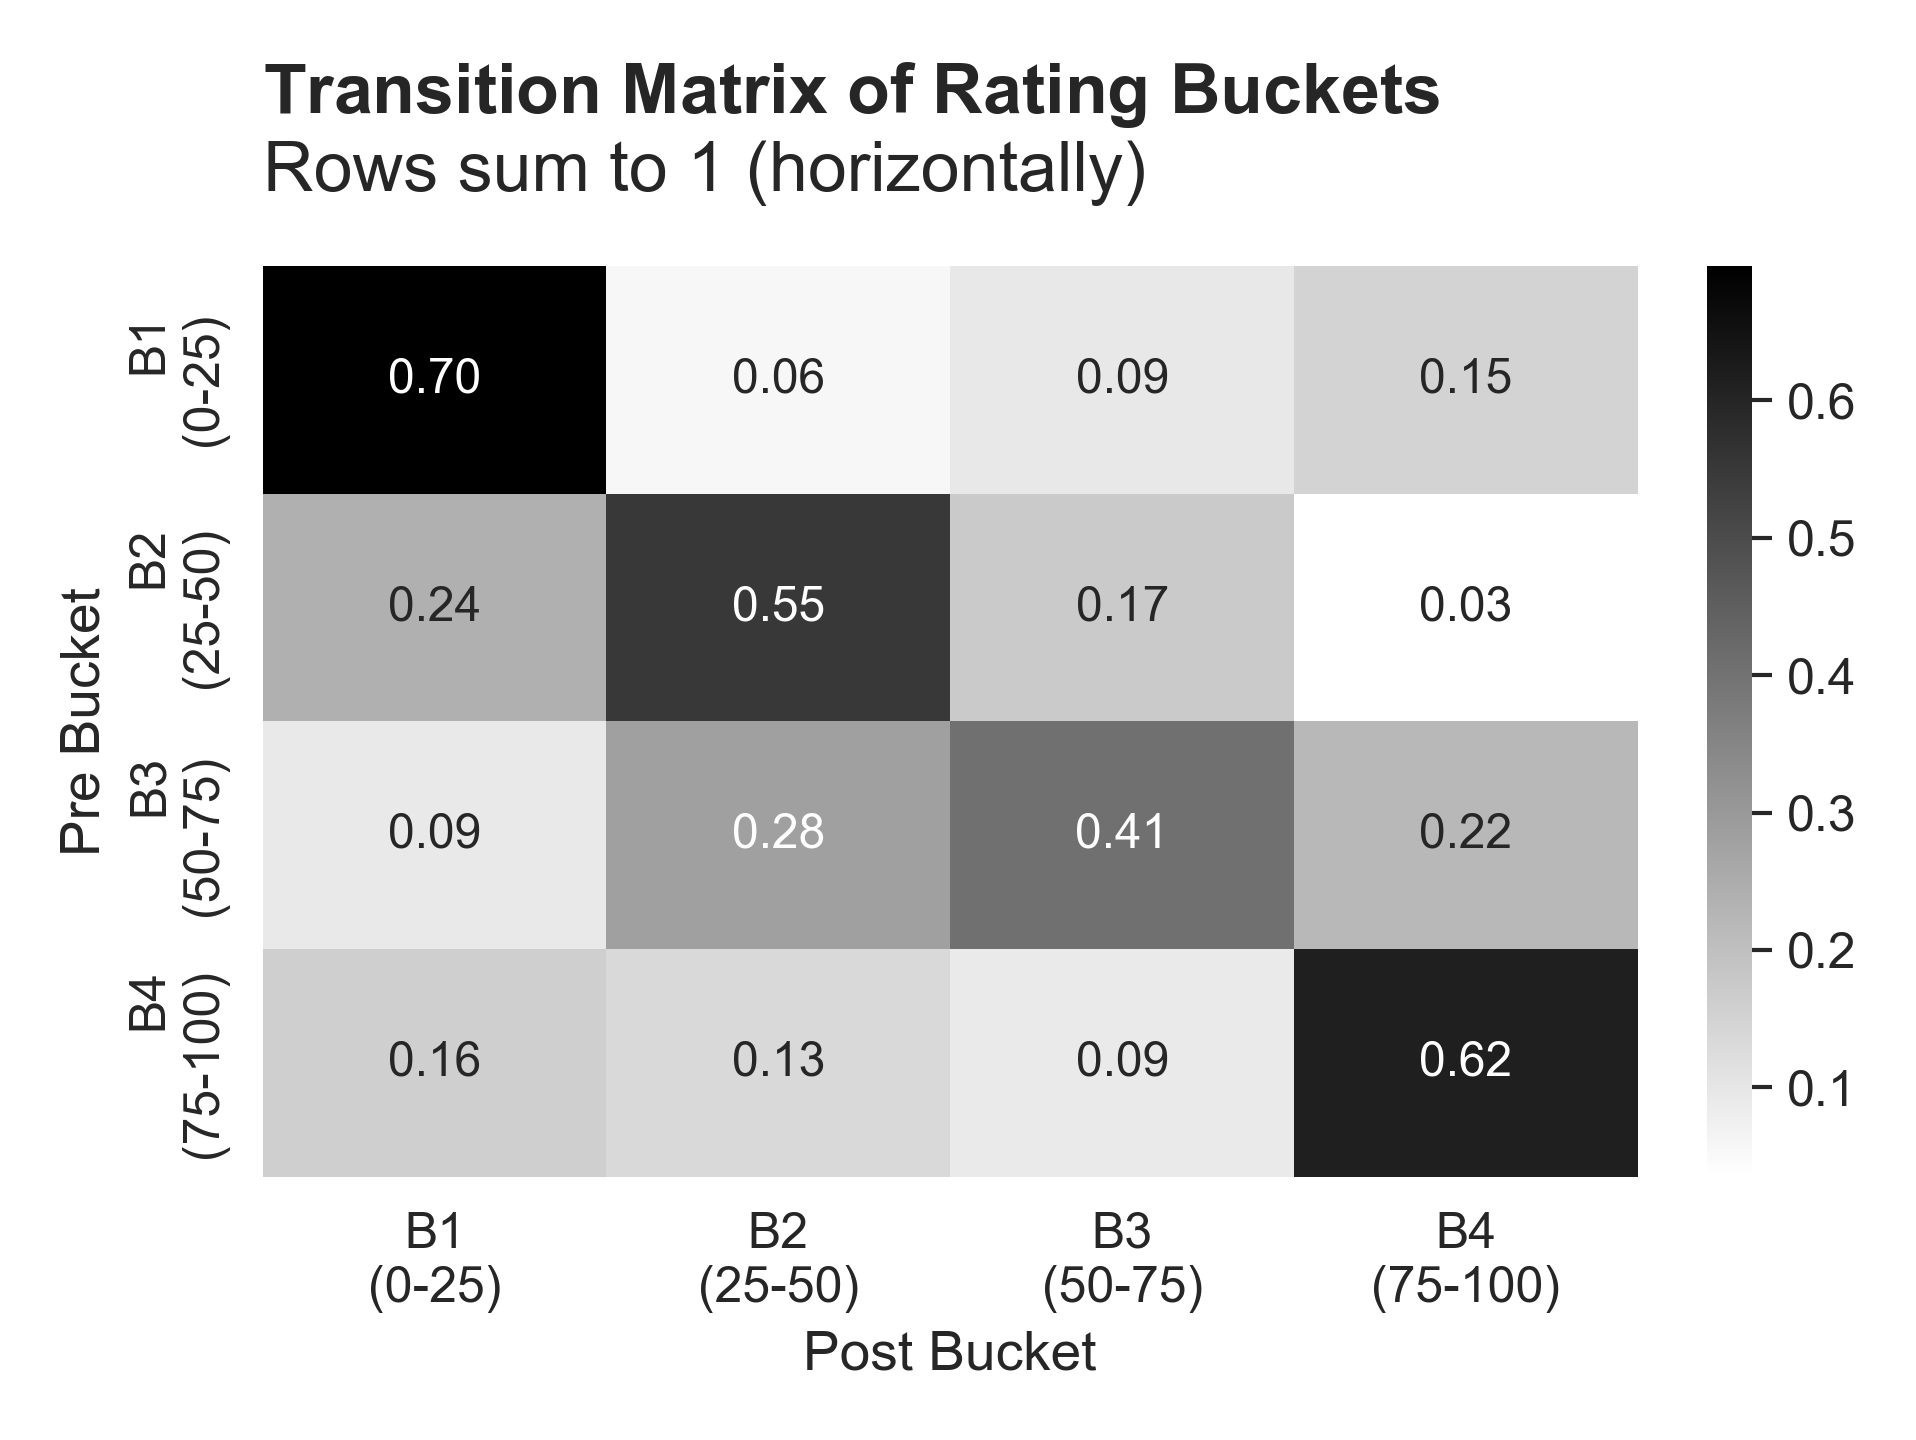

In [109]:
def is_extreme(x):
    return x < 10 or x > 90

def bucket_label(x, n_bins):
    bins = np.linspace(0, 100, n_bins + 1)
    labels = [f"B{i+1}\n({int(bins[i])}-{int(bins[i+1])})" for i in range(n_bins)]
    return pd.cut([x], bins=bins, labels=labels, include_lowest=True)[0]


from src.helpers import make_aesthetic
mypal = make_aesthetic(font_scale=1.2)


df['pre_extreme'] = df['pre'].apply(is_extreme)
df['post_extreme'] = df['post'].apply(is_extreme)


# Transition matrix of extremes
####################################
####################################
sns.heatmap(
    pd.crosstab(df['pre_extreme'], df['post_extreme'], normalize='index'),
    annot=True, fmt=".2f", cmap="binary"
)
plt.xlabel("Post Extreme (<=10 or >=90)")
plt.ylabel("Pre Extreme (<=10 or >=90)")
plt.title(f"{make_bold("Transition Matrix of Extreme Ratings")}\nRows sum to 1 (horizontally)")
plt.show()
####################################
####################################

# Transition matrix of pre/post buckets
####################################
####################################
N_BINS=4
df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['post_bucket'] = df['post'].apply(bucket_label, n_bins=N_BINS)
sns.heatmap(
    pd.crosstab(df['pre_bucket'], df['post_bucket'], normalize='index'),
    annot=True, fmt=".2f", cmap="binary"
)
plt.xlabel("Post Bucket")
plt.ylabel("Pre Bucket")
plt.title(f"{make_bold("Transition Matrix of Rating Buckets")}\nRows sum to 1 (horizontally)")
####################################
####################################



####################################

In [110]:
pd.crosstab(df['pre_bucket'], df['post_bucket'])

post_bucket,B1\n(0-25),B2\n(25-50),B3\n(50-75),B4\n(75-100)
pre_bucket,,,,
B1\n(0-25),37,3,5,8
B2\n(25-50),7,16,5,1
B3\n(50-75),3,9,13,7
B4\n(75-100),18,15,10,69


## Where changes come from

Text(0, 0.5, 'Effect')

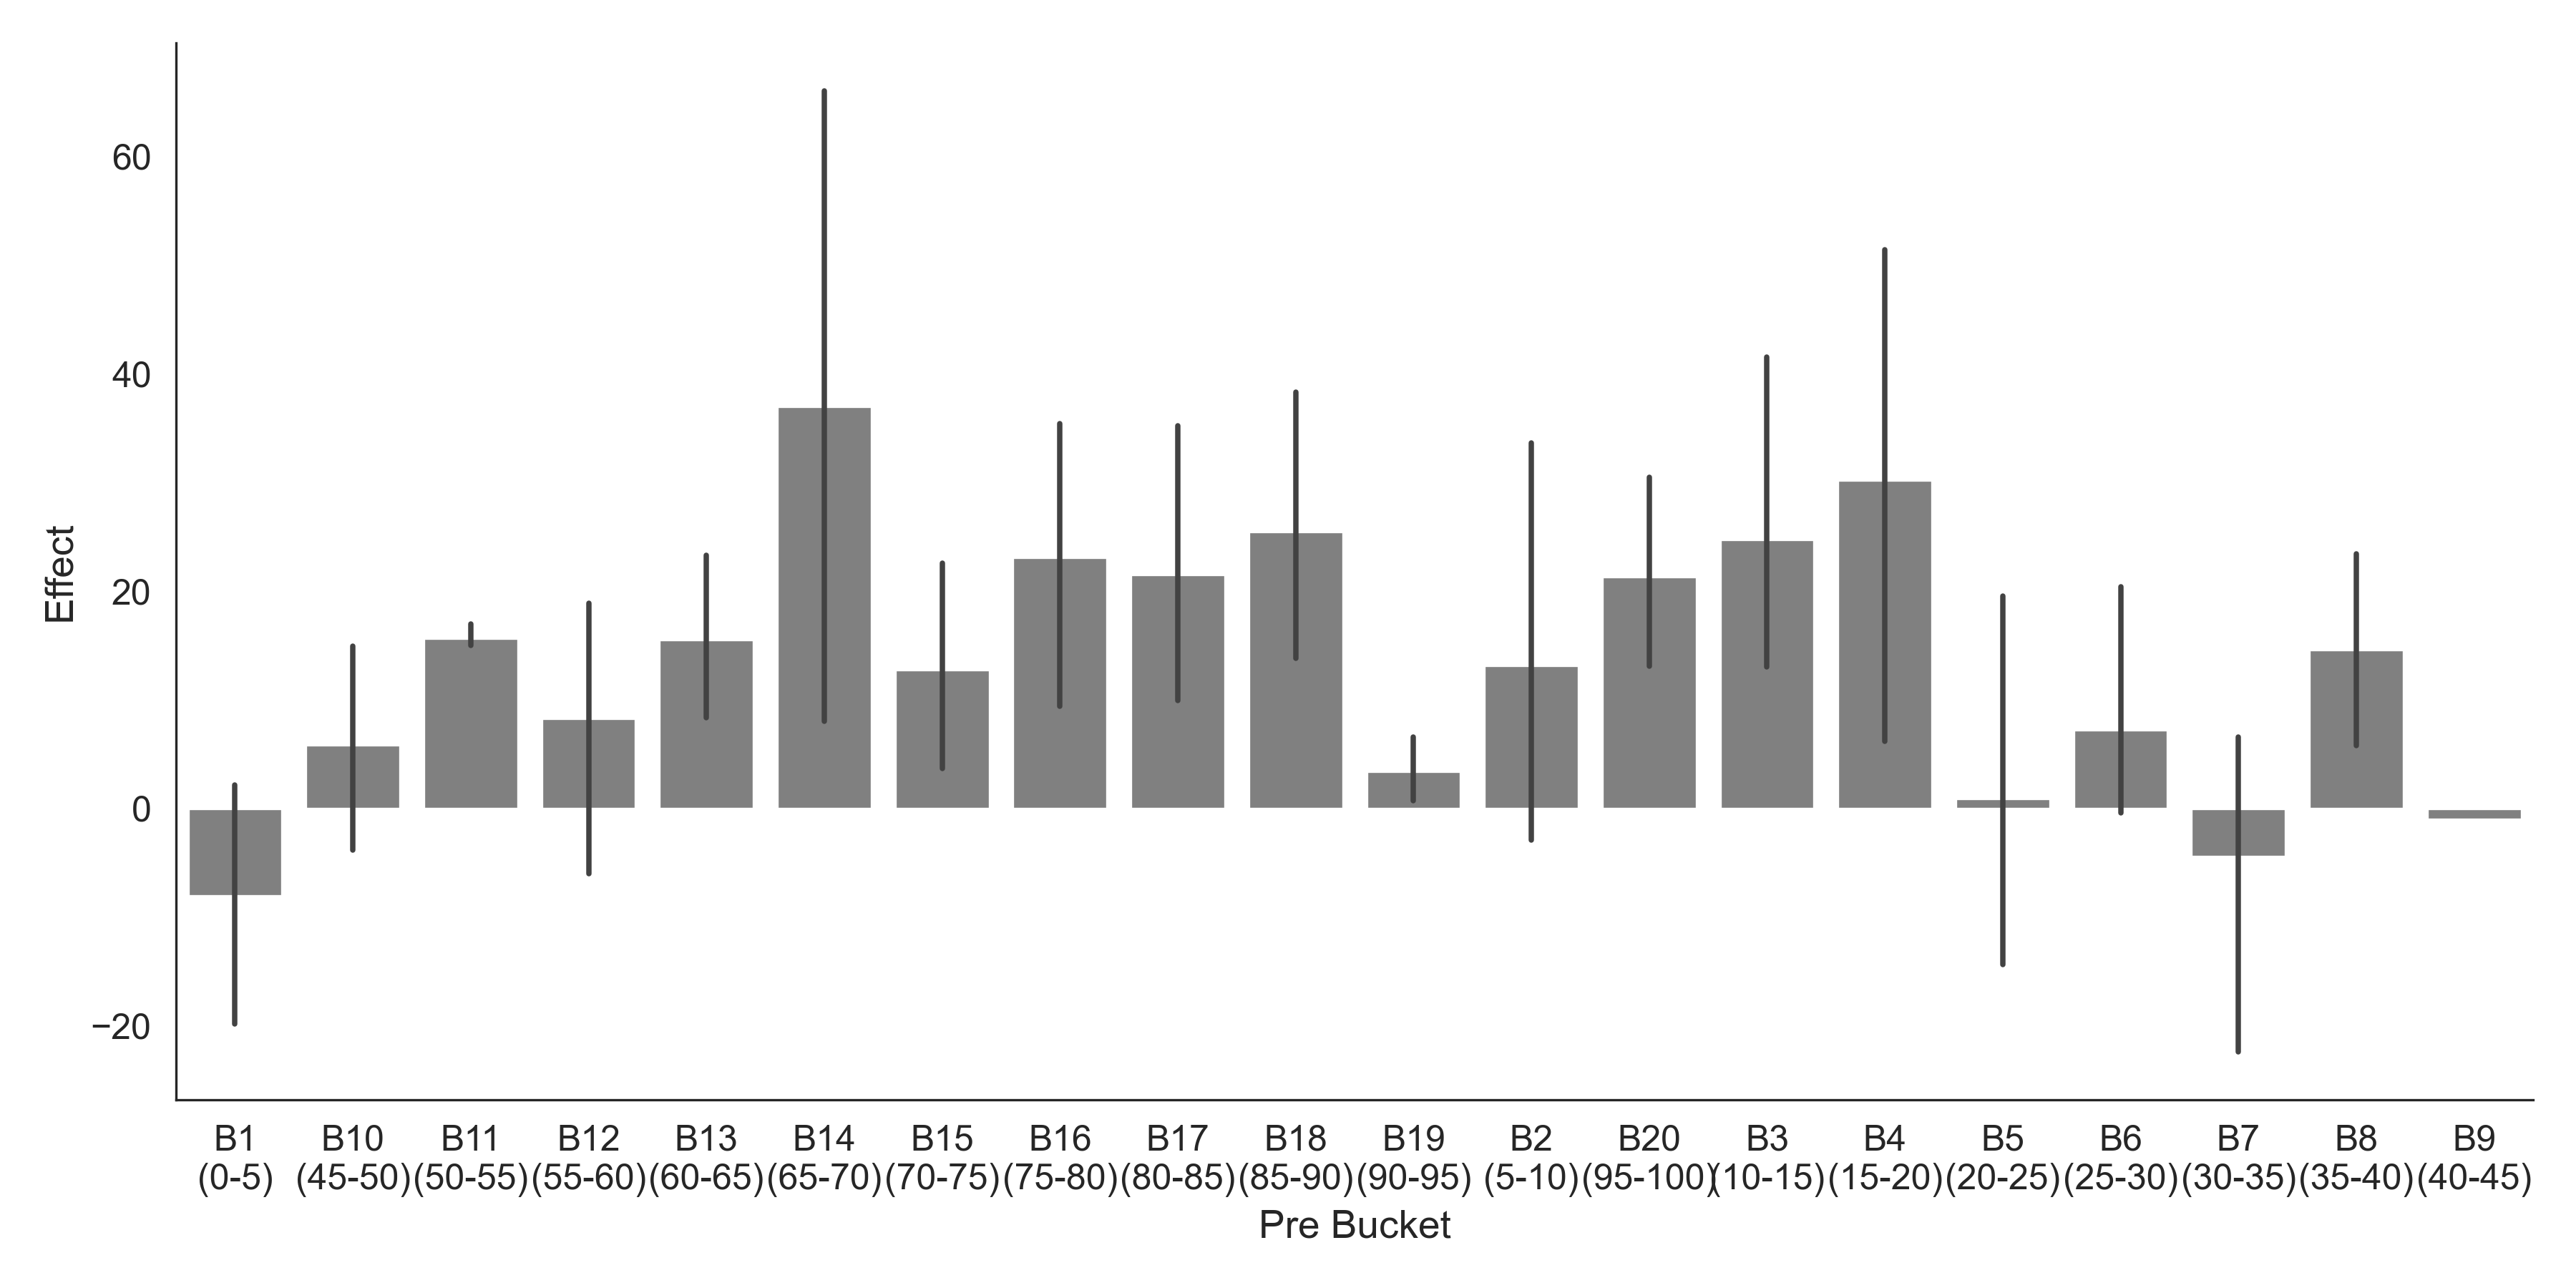

In [115]:
N_BINS=20
df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['post_bucket'] = df['post'].apply(bucket_label, n_bins=N_BINS)
df = df.sort_values(by=['pre_bucket'])
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='pre_bucket', y='change_distance', color='gray')
# sns.lineplot(data=df, x='pre_bucket', y='change_distance', color='gray')
plt.xlabel("Pre Bucket")
plt.ylabel("Effect")


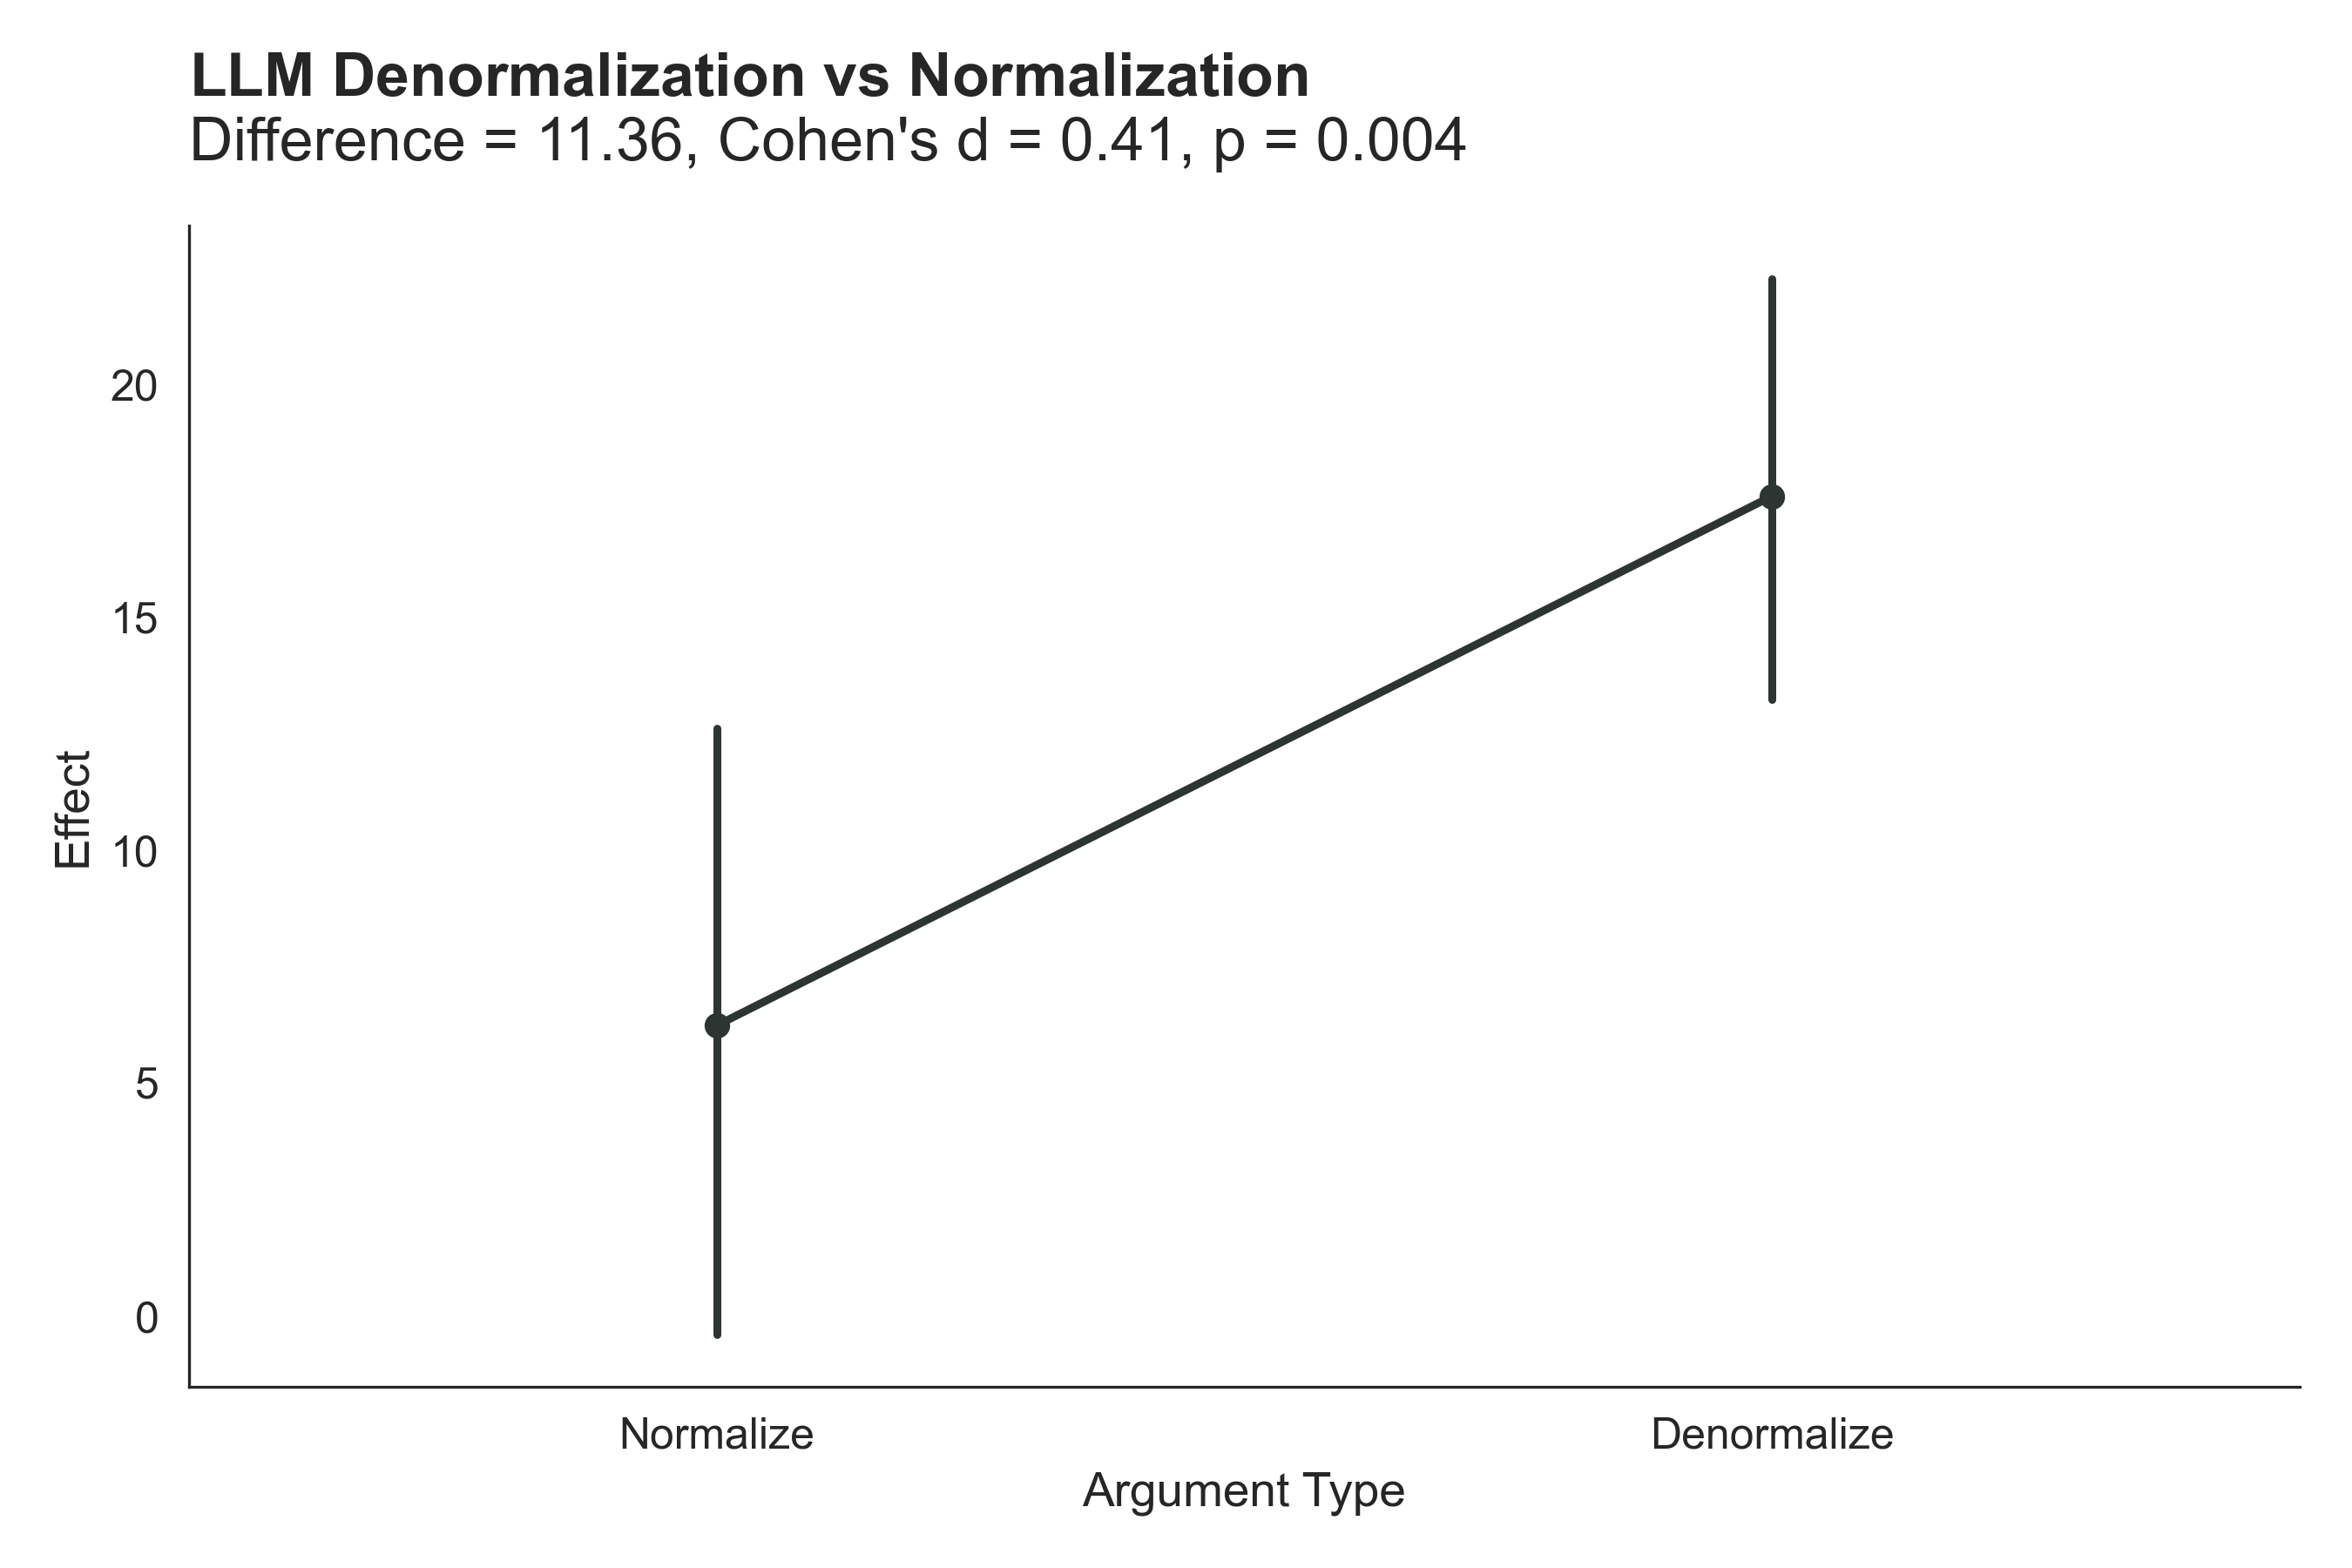

In [99]:
from scipy.stats import permutation_test

def cohens_d(x, y):
   nx, ny = len(x), len(y)
   pooled_std = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
   return (np.mean(x) - np.mean(y)) / pooled_std

def statistic(x, y):
   return np.mean(x) - np.mean(y)

df['convince_type'] = np.where(df['rating'] < df['pre'], "Denormalize", "Normalize")
denorm = df[df['convince_type'] == 'Denormalize']['change_distance']
norm = df[df['convince_type'] == 'Normalize']['change_distance']
cohens_d = cohens_d(denorm, norm)


res = permutation_test((denorm, norm), statistic, n_resamples=10000, alternative='two-sided', random_state=42)

plt.figure(figsize=(9, 6))
sns.pointplot(data=df, x='convince_type', y='change_distance')

plt.ylabel("Effect")
plt.xlabel("Argument Type")
plt.title(f"{make_bold('LLM Denormalization vs Normalization')}\nDifference = {res.statistic:.2f}, Cohen's d = {cohens_d:.2f}, p = {res.pvalue:.3f}")
plt.show()

# Individual differences

<Axes: xlabel='change_distance', ylabel='pid'>

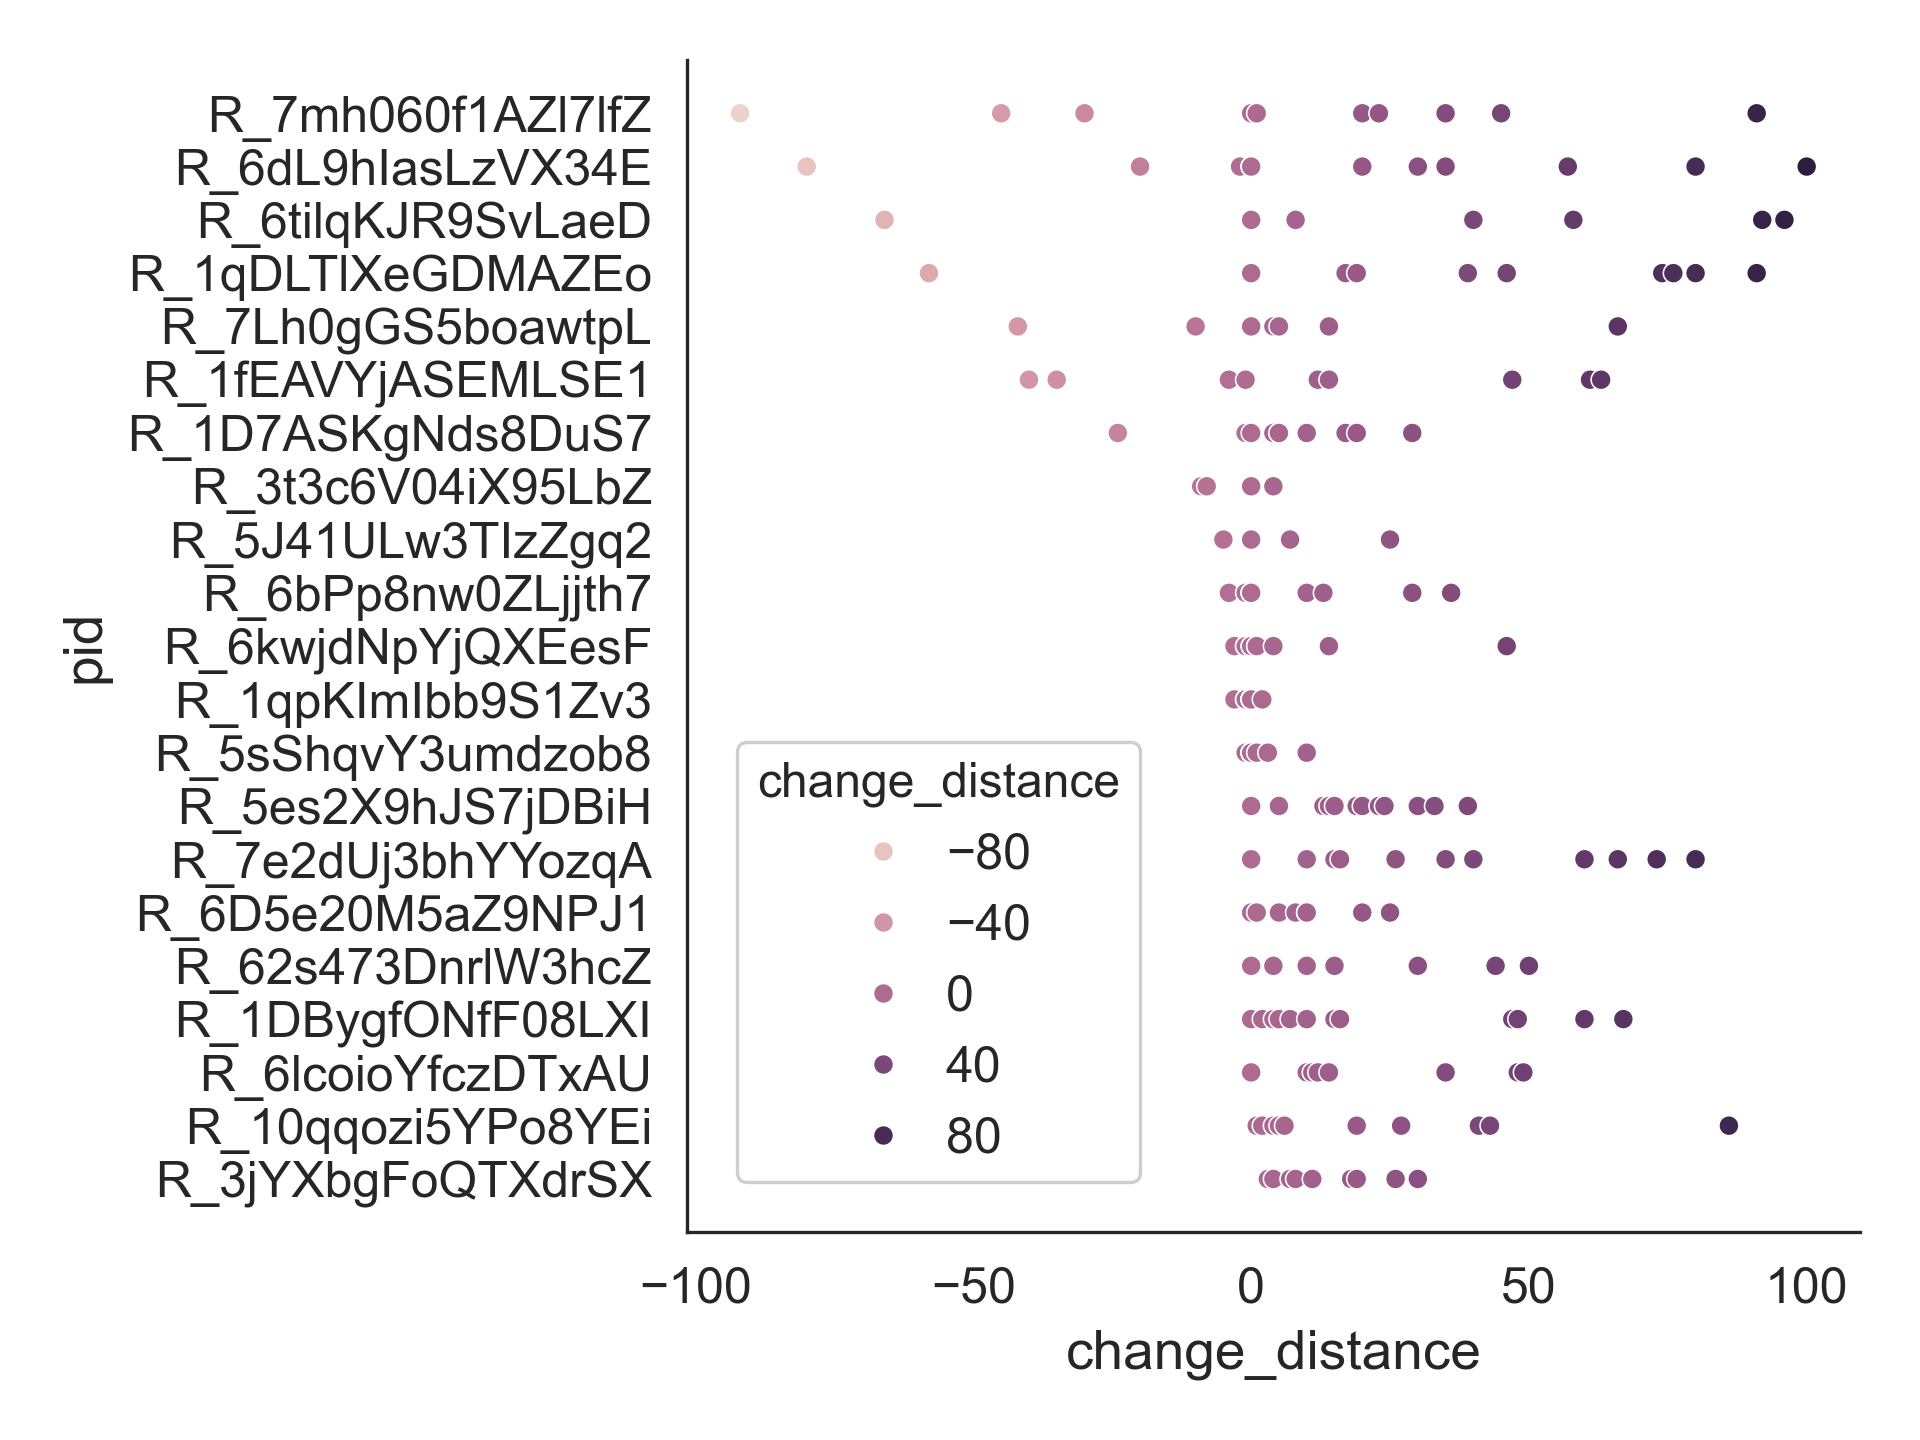

In [100]:
pid_cols = [c for c in df.columns if "usage" in c] + ["pid", "feedback"]

byp = (
    df.groupby(pid_cols)['change_distance']
      .agg(mean=np.mean, sd=np.std)
      .reset_index()
)
sns.scatterplot(data=df.sort_values(by=['change_distance']), y='pid', x='change_distance', hue='change_distance')


# How frequently do ppl use LLMs?

     usage_type  proportion    ci_low   ci_high  count  total
0      Personal    0.666667  0.354202  0.879416      6      9
1         Moral    0.666667  0.354202  0.879416      6      9
2  Conventional    0.555556  0.266651  0.811221      5      9
3     Any Usage    0.666667  0.354202  0.879416      6      9


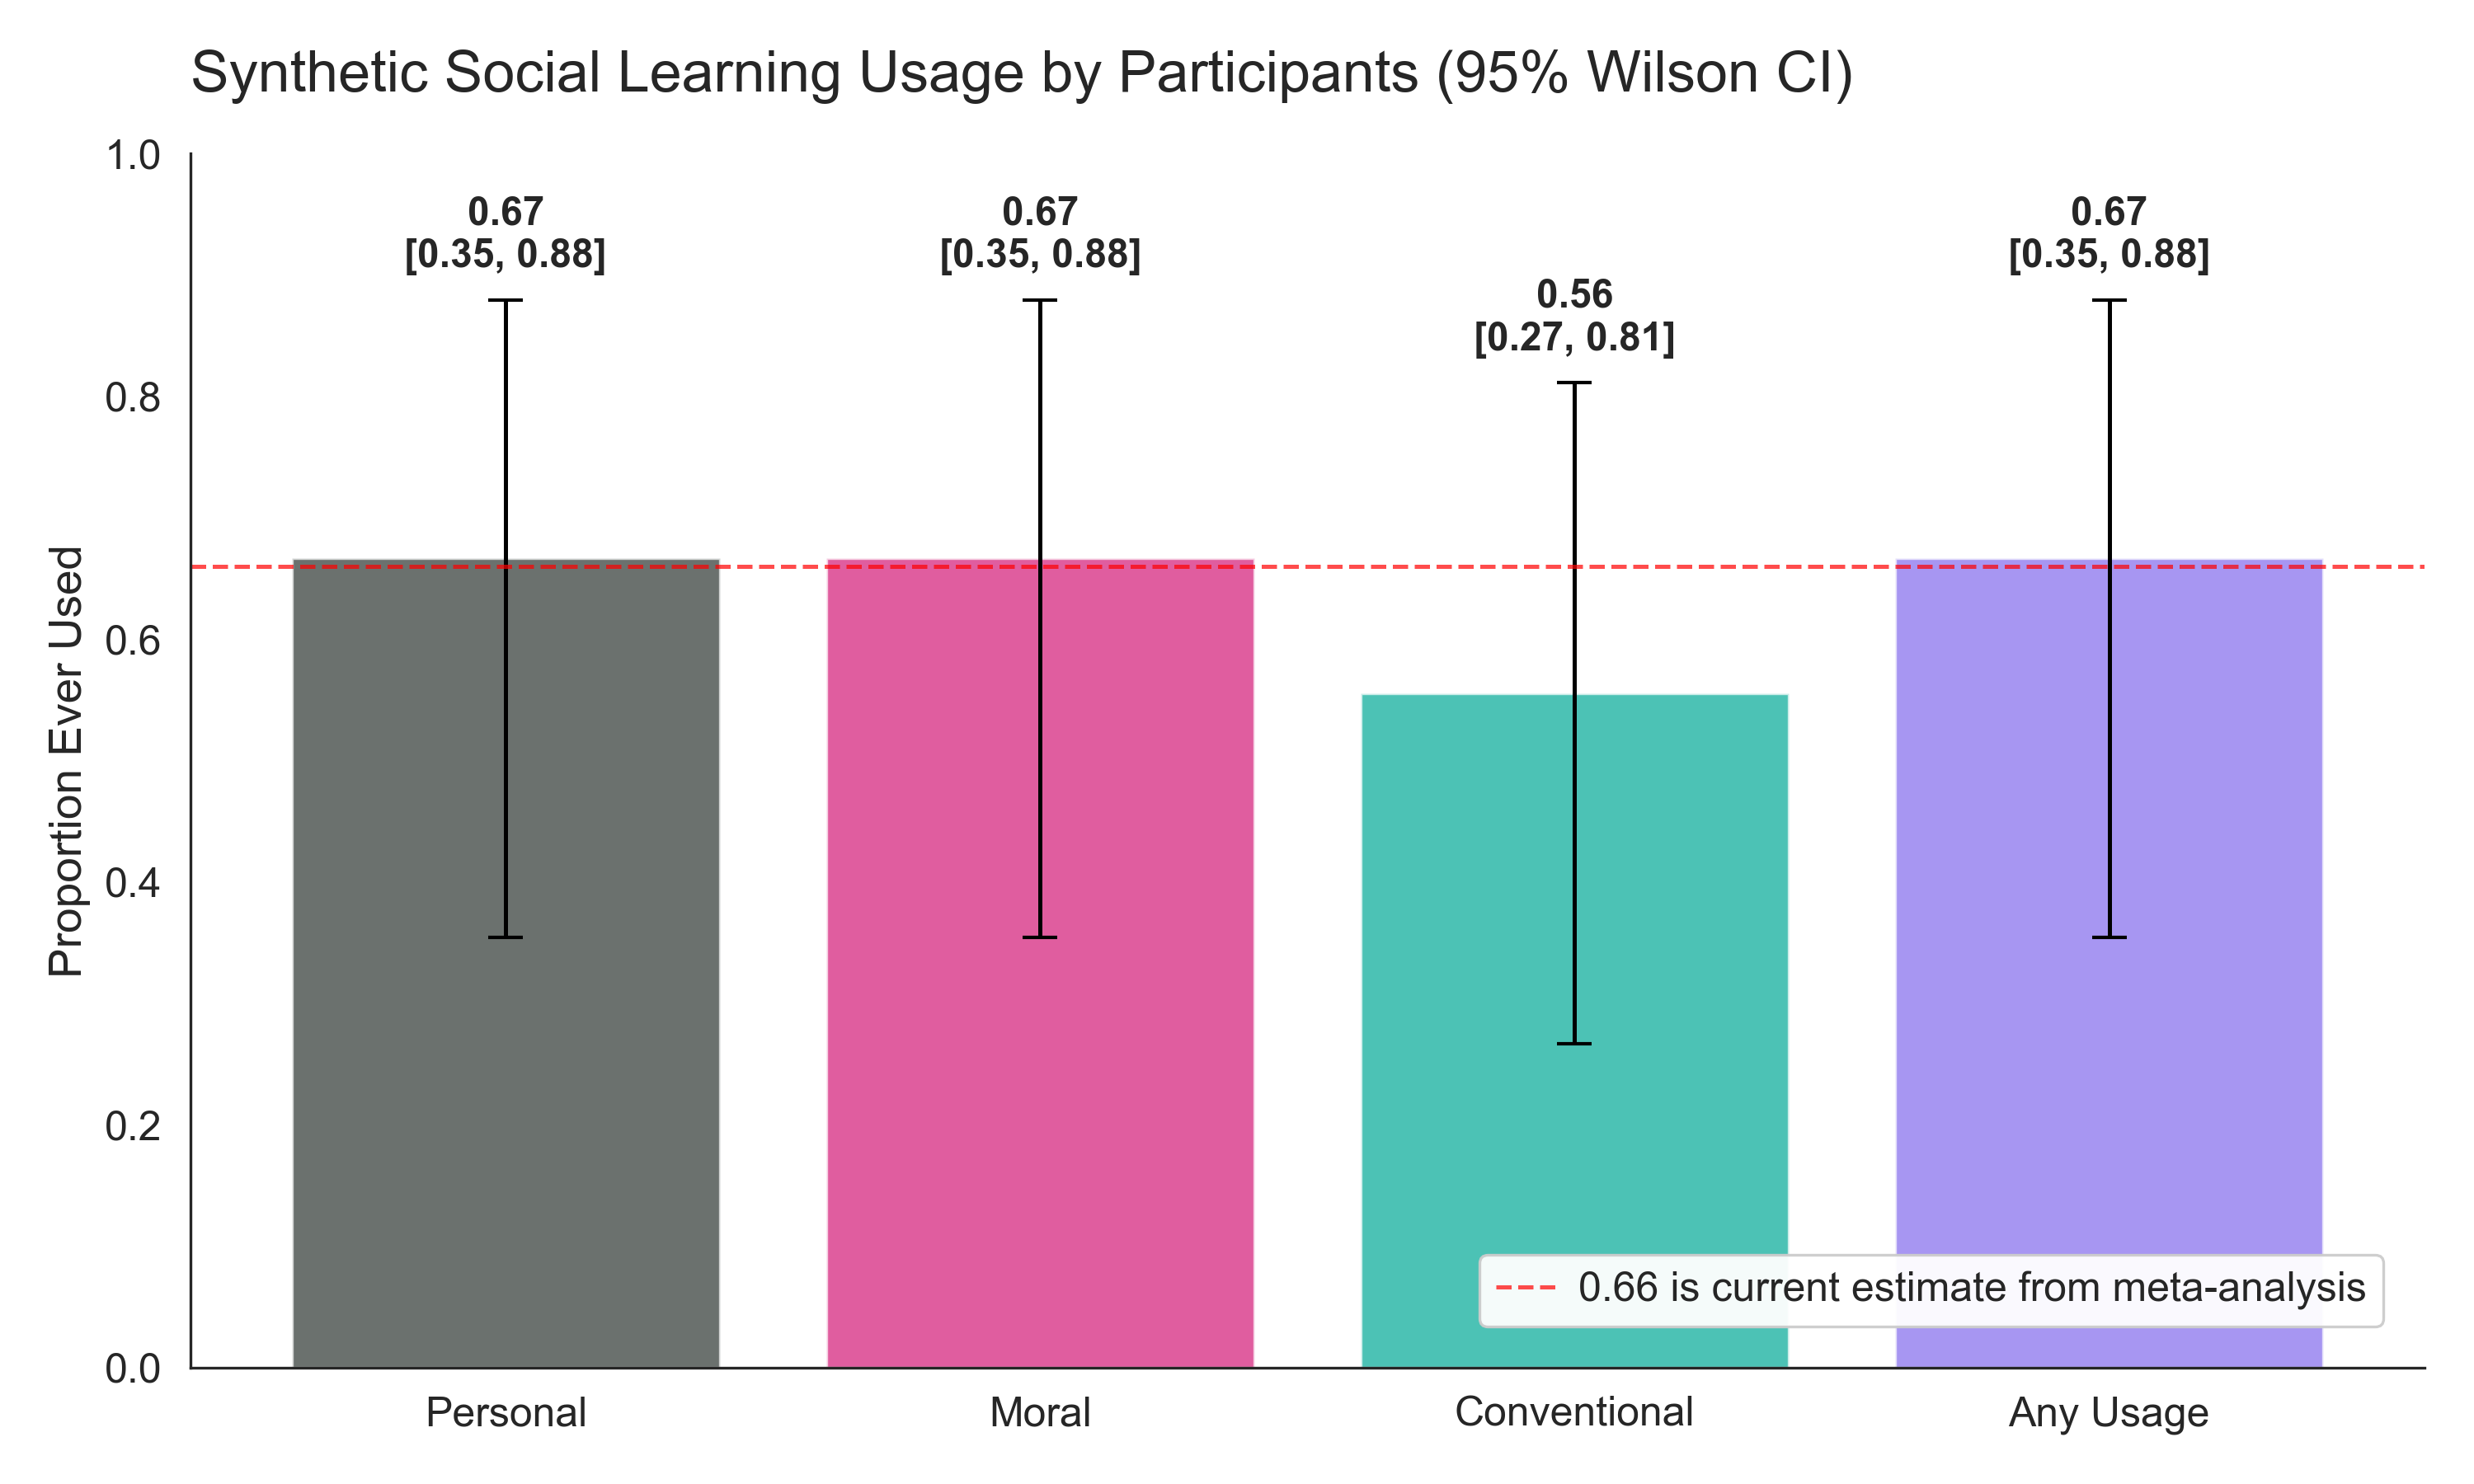

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint

from src.helpers import make_aesthetic


# Get color palette
mypal = make_aesthetic(font_scale=1.2)


# Create the any usage indicator
##################################################

byp['any_usage'] = ((byp['usage_personal_binary'] == 1) |
                   (byp['usage_moral_binary'] == 1) |
                   (byp['usage_convention_binary'] == 1)).astype(int)


# Get wilson CIs
##################################################
usage_vars = ['usage_personal_binary', 'usage_moral_binary', 'usage_convention_binary', 'any_usage']
labels = ['Personal', 'Moral', 'Conventional', 'Any Usage']
summary_data = []
for var, label in zip(usage_vars, labels):
    count = byp[var].sum()
    total = len(byp)
    prop = count / total
    ci_low, ci_high = proportion_confint(count, total, method='wilson')

    summary_data.append({
        'usage_type': label,
        'proportion': prop,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'count': count,
        'total': total
    })

usage_df = pd.DataFrame(summary_data)
print(usage_df)


# Plot
##################################################
plt.figure(figsize=(10, 6))
bars = plt.bar(usage_df['usage_type'], usage_df['proportion'],
               color=mypal[:len(usage_df)], alpha=0.7)
errors = [usage_df['proportion'] - usage_df['ci_low'],
          usage_df['ci_high'] - usage_df['proportion']]
plt.errorbar(usage_df['usage_type'], usage_df['proportion'], yerr=errors,
             fmt='none', color='black', capsize=5)
for i, row in usage_df.iterrows():
    plt.text(i, row['ci_high'] + 0.02, f"{row['proportion']:.2f}\n[{row['ci_low']:.2f}, {row['ci_high']:.2f}]",
             ha='center', va='bottom', fontweight='bold')

plt.ylabel('Proportion Ever Used')
plt.axhline(y=0.66, color='red', linestyle='--', alpha=0.7, label="0.66 is current estimate from meta-analysis")
plt.legend(loc='lower right')
plt.title('Synthetic Social Learning Usage by Participants (95% Wilson CI)')
plt.ylim(0, 1)
plt.show()

Text(0.0, 1.0, 'Avg Effect (Pre Distance minus Post Distance)\nby Synthetic Social Knowledge Usage')

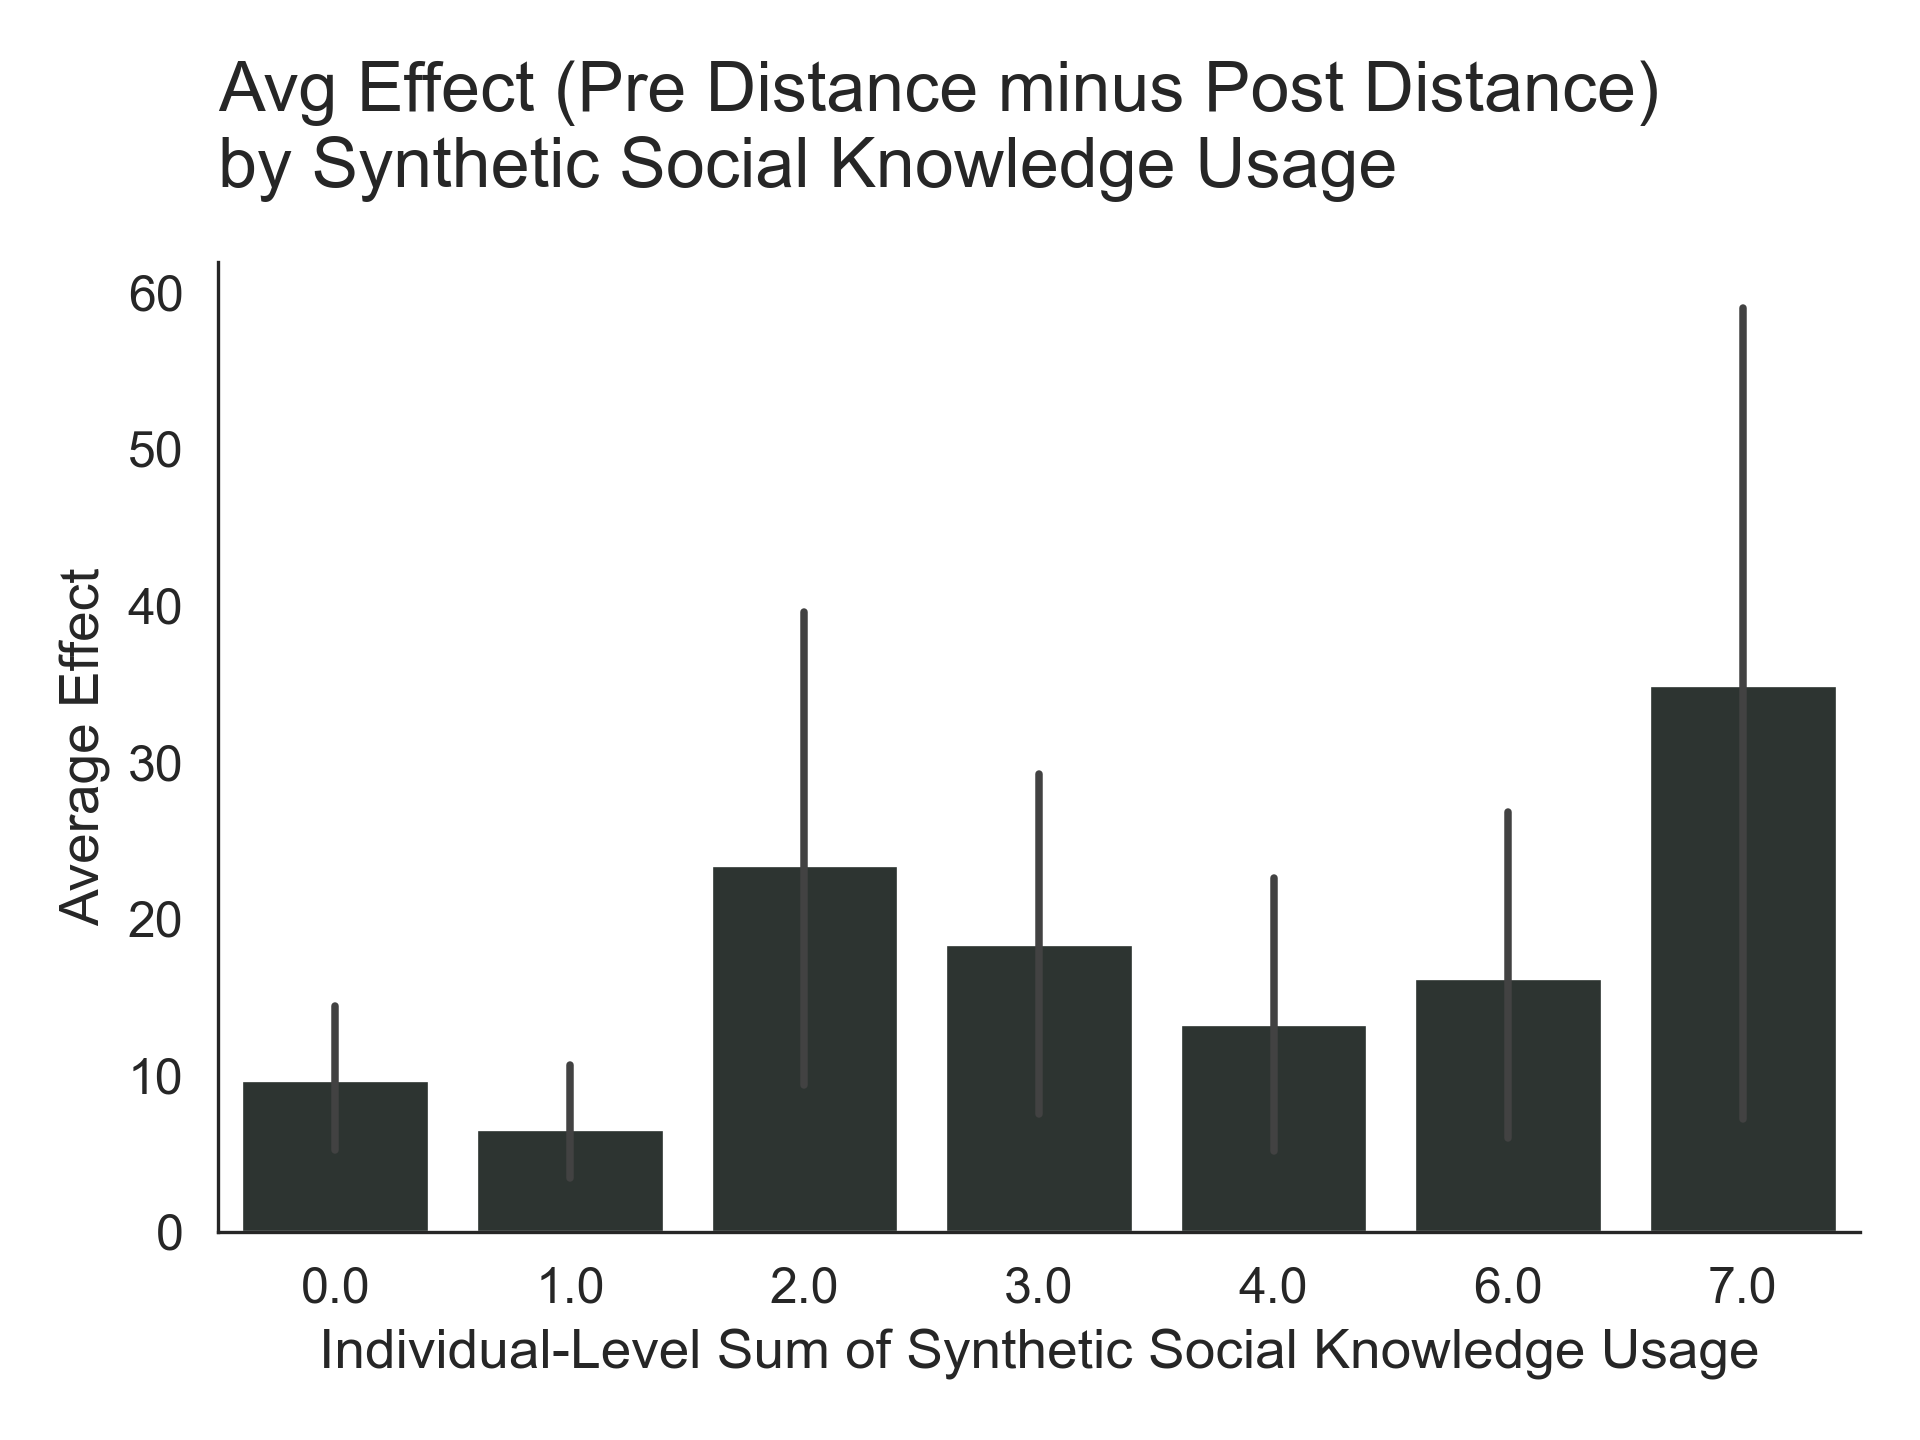

In [121]:
usage_map = {
   "No - never used": 0,
   "Yes - less often than several times a week": 1,
   "Yes - several times a week": 2,
   "Yes - about once a day": 3,
   "Yes - several times a day": 4
}

df['any_usage'] = ((df['usage_personal_binary'] == 1) |
                   (df['usage_moral_binary'] == 1) |
                   (df['usage_convention_binary'] == 1)).astype(int)

for var in ['usage_personal', 'usage_moral', 'usage_convention']:
    df[f"{var}_int"] = df[var].map(usage_map)
df['usage_sum'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].sum(axis=1)

sns.barplot(data=df, x='usage_sum', y='change_distance')
plt.xlabel("Individual-Level Sum of Synthetic Social Knowledge Usage")
plt.ylabel("Average Effect")
plt.title("Avg Effect (Pre Distance minus Post Distance)\nby Synthetic Social Knowledge Usage")

# Qual

## Overall feedback

In [9]:
for idx, row in byp.dropna(subset=['feedback']).sort_values(by=['mean'], ascending=False).iterrows():
    print(f"PID: {row['pid']}")
    print(f"Mean Change: {row['mean']:.2f}")
    print(f"Feedback: {row['feedback']}")
    print("====")


PID: R_1qDLTlXeGDMAZEo
Mean Change: 34.91
Feedback: No
====
PID: R_1DBygfONfF08LXI
Mean Change: 23.42
Feedback: I changed my mind a few times if I agreed with the reasoning. Other times, I simply didn't agree and stuck to my guns. 
====
PID: R_10qqozi5YPo8YEi
Mean Change: 23.40
Feedback: none. I found some of the explanations very helpful. They changed my mind at times
====
PID: R_6dL9hIasLzVX34E
Mean Change: 23.08
Feedback: In some cases I read the AI argument and I changed my mind as its argument I felt it is making sense.
====
PID: R_6lcoioYfczDTxAU
Mean Change: 19.89
Feedback: I seemed to be using "how reasonable" it was as my guide. If AI presented reasonable and logical arguments it changed my mind. 
====
PID: R_5es2X9hJS7jDBiH
Mean Change: 18.46
Feedback: I changed based on convincing points.
====
PID: R_6D5e20M5aZ9NPJ1
Mean Change: 7.62
Feedback: I think the last one about divorce, I was mainly thinking of how  weird it would feel but the AI explained many reasons why divorcees

## Trial level

In [10]:
from src.sbert_clusterer import SBERTClusterer
qdf = df.dropna(subset=['qual'])

qdf = df.dropna(subset=['qual']).copy()
qdf['change_distance_q'] = pd.qcut(qdf['change_distance'], 3).cat.codes + 1


clusterer = SBERTClusterer()
results = {}  # store results for each quartile bin

for q in sorted(qdf['change_distance_q'].unique()):
    print("="*80)
    print(f"Clustering for qcut bin: {q}")
    print("="*80)

    texts = qdf.loc[qdf['change_distance_q'] == q, 'qual'].tolist()

    if len(texts) < 2:
        print(f"Not enough texts for clustering in bin {q}. Skipping.")
        continue

    best_k = clusterer.find_k(texts, k_min=2, k_max=10, plot=False)

    clustered_df = clusterer.apply_clustering(texts, k=best_k)

    results[q] = {
        "best_k": best_k,
        "clustered_df": clustered_df,
        "summary": clusterer.get_cluster_summary()
    }



Clustering for qcut bin: 1


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Best k: 9 with silhouette score: 0.049

Cluster 0 (Centroid: 'You can be honest without saying everything you think.'):
['Agreed. Unless withholding said knowledge causes irreparable harm to you, I am not obligated to inform you of it - no matter how (subjectively) important you think it is.', '"it can be seen as dishonest" is different from "it\'s dishonest"', 'You can be honest without saying everything you think.', 'Reasoning is sound']

Cluster 1 (Centroid: 'I'd give the rule-of-thumb, "It's rude to control other people," a 95 on a scale of 0 to 100.  This rule aligns strongly with core ethical principles such as autonomy and respect for individuals. Controlling behavior, whether it's through manipulation, coercion, or micro-management, disregards a person's right to make their own choices and govern their own life. It undermines trust and can cause significant psychological harm, leading to resentment and conflict. While there are a few exceptions, such as a parent protecting a ch

# Spaghetti plot

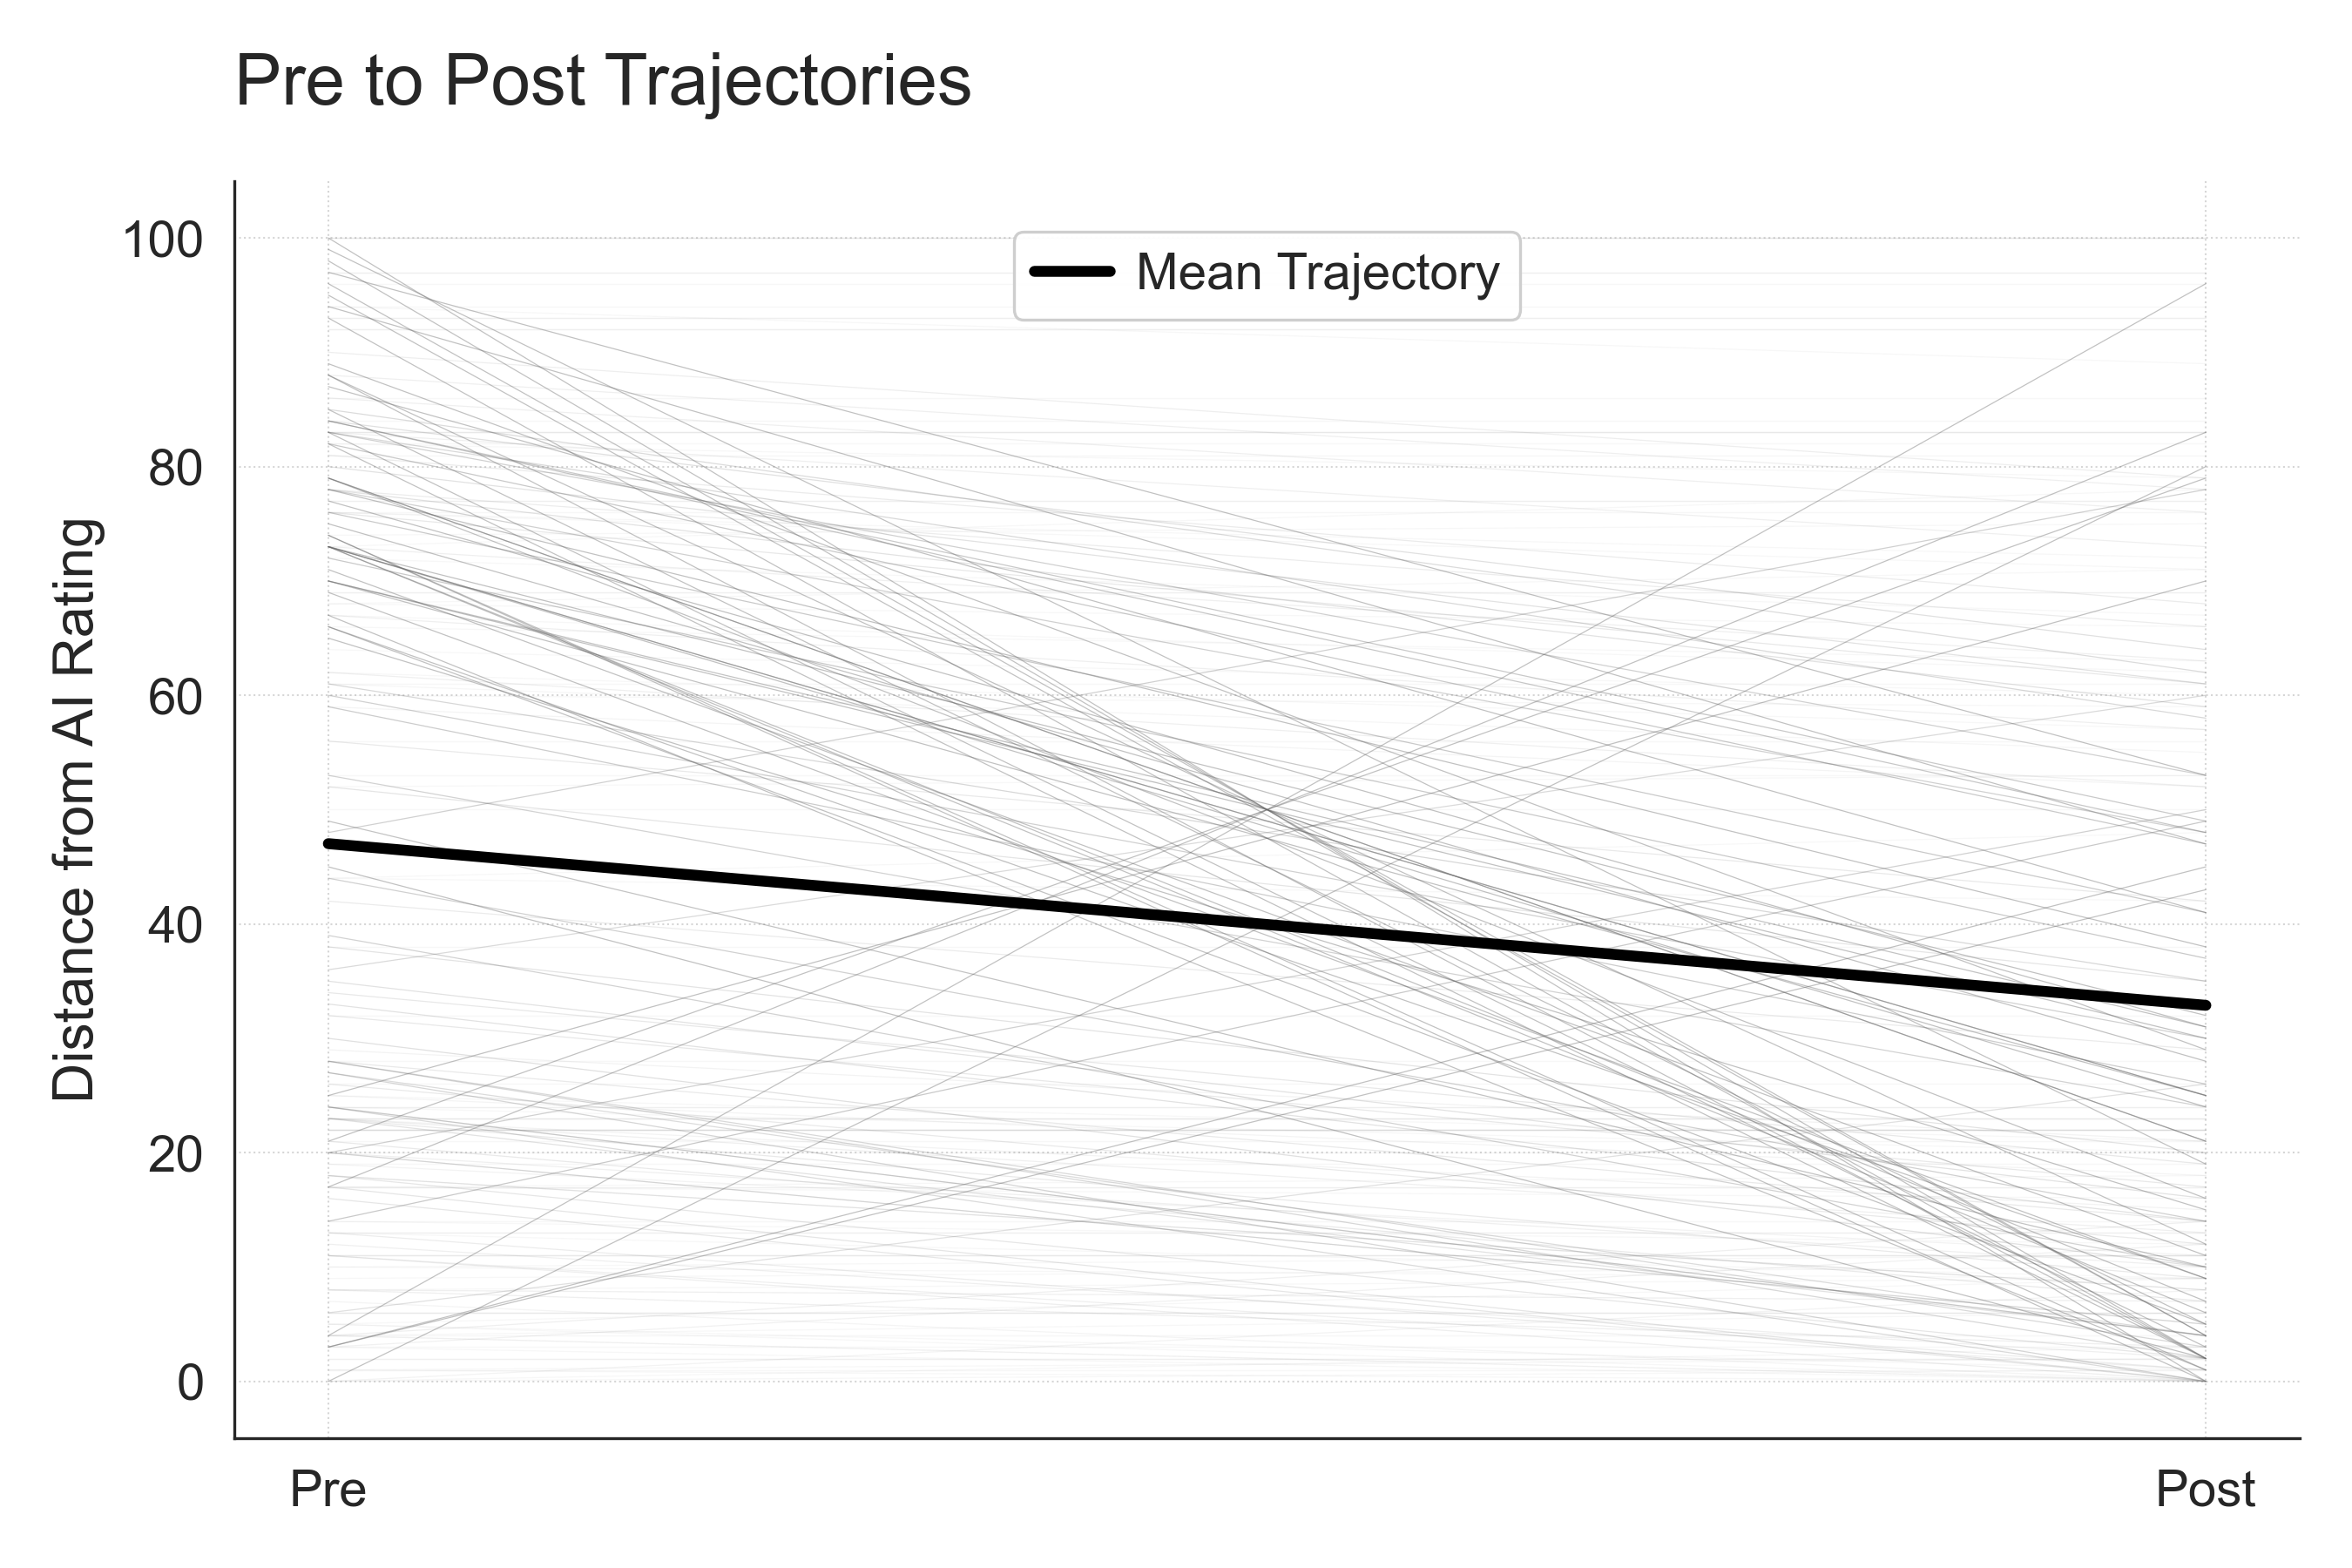

In [37]:

mypal = make_aesthetic(font_scale=1.4)
fig, ax = plt.subplots(figsize=(9, 6))

# Individual trajectories
for i in range(len(df)):
    pre_val = df['pre_distance'].iloc[i]
    post_val = df['post_distance'].iloc[i]
    change = abs(pre_val - post_val)
    color = '#666666'
    alpha = min(0.4, max(0.05, change / df['change_distance'].abs().max()))
    ax.plot([0, 1], [pre_val, post_val], color=color, alpha=alpha, linewidth=0.3)

# Mean trajectory
ax.plot([0, 1], [df['pre_distance'].mean(), df['post_distance'].mean()],
        'black', linewidth=3, label='Mean Trajectory')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Pre', 'Post'])
ax.set_ylabel('Distance from AI Rating')
ax.set_title("Pre to Post Trajectories")
ax.legend()
ax.grid(True, alpha=0.8)

plt.show()